In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('datos_curados.csv')
df

,Localidad,Cultivar,Repetición,α Tocopherol,γ Tocopherol,δ Tocopherol,α+γ+δ Tocopherol,Palmitic Acid,Palmitoleic Acid,Stearic Acid,...,inicio de floración IF,Madurez fisiologica MF,Dur S-IF,Dur S-MF,Dur IF-MF,Tmx IF-MF,Tmed IF-MF,T mn IF-MF,pp IF-MF,etp IF- MF
0,Loc_1,cv_1,1,502.64,826.36,6.18,1335.18,4.26,0.20,2.04,...,2012-10-04,2012-11-26,157,211,54,29.9,23.05,17.1,214.0,222.8
1,Loc_1,cv_1,2,511.20,788.10,7.36,1306.66,4.24,0.20,1.96,...,2012-10-04,2012-11-26,157,211,54,29.9,23.05,17.1,214.0,222.8
2,Loc_1,cv_2,1,317.95,726.27,0.00,1044.22,3.96,0.17,1.89,...,2012-09-29,2012-11-25,152,210,58,28.7,21.70,15.0,214.9,232.1
3,Loc_1,cv_2,2,356.28,796.46,7.22,1159.96,4.45,0.19,2.21,...,2012-09-29,2012-11-25,152,210,58,28.7,21.70,15.0,214.9,232.1
4,Loc_1,cv_3,1,405.68,745.75,3.79,1155.22,4.17,0.17,1.95,...,2012-09-23,2012-11-17,146,202,56,28.7,21.70,15.0,185.3,225.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,Loc_4,cv_11,2,301.55,529.71,10.12,841.38,3.90,0.13,1.95,...,2012-09-18,2012-11-18,126,187,62,21.3,15.00,8.7,0.0,196.0
100,Loc_4,cv_12,1,307.06,558.40,1.97,867.43,4.01,0.20,2.06,...,2012-09-13,2012-11-15,121,184,64,21.3,14.90,8.5,0.0,196.9
101,Loc_4,cv_12,2,321.44,631.59,4.95,957.98,3.96,0.16,1.59,...,2012-09-13,2012-11-15,121,184,64,21.3,14.90,8.5,0.0,196.9
102,Loc_4,cv_13,1,284.28,621.01,7.25,912.54,3.94,0.18,2.06,...,2012-09-12,2012-11-15,120,184,65,21.3,14.90,8.4,0.0,194.3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Localidad               104 non-null    object 
 1   Cultivar                104 non-null    object 
 2   Repetición              104 non-null    int64  
 3   α Tocopherol            104 non-null    float64
 4   γ Tocopherol            104 non-null    float64
 5   δ Tocopherol            104 non-null    float64
 6   α+γ+δ Tocopherol        104 non-null    float64
 7   Palmitic Acid           104 non-null    float64
 8   Palmitoleic Acid        104 non-null    float64
 9   Stearic Acid            104 non-null    float64
 10  Oleic Acid              104 non-null    float64
 11  Linoleic Acid           104 non-null    float64
 12  Linolenic Acid          104 non-null    float64
 13  Arachidic Acid          104 non-null    float64
 14  Ecosenoic Acid          104 non-null    fl

2) ¿Cómo agruparía los cultivares con base en la similitud del perfil de ácidos grasos, tocoferoles
e índice de estabilidad?

In [ ]:
df.columns

Index(['Localidad', 'Cultivar', 'Repetición', 'α Tocopherol', 'γ Tocopherol',
       'δ Tocopherol', 'α+γ+δ Tocopherol', 'Palmitic Acid', 'Palmitoleic Acid',
       'Stearic Acid', 'Oleic Acid', 'Linoleic Acid', 'Linolenic Acid',
       'Arachidic Acid', 'Ecosenoic Acid', 'OSI', 'Oil content', 'Código',
       'IV', 'Fecha de siembra S', 'inicio de floración IF',
       'Madurez fisiologica MF', 'Dur S-IF', 'Dur S-MF', 'Dur IF-MF',
       'Tmx IF-MF', 'Tmed IF-MF', 'T mn IF-MF', 'pp IF-MF', 'etp IF- MF'],
      dtype='object')

In [3]:
df_2 = df.copy()
df_2 = df_2[['Cultivar', 'Repetición', 'α Tocopherol', 'γ Tocopherol',
             'δ Tocopherol', 'α+γ+δ Tocopherol', 'Palmitic Acid',
             'Palmitoleic Acid', 'Stearic Acid', 'Oleic Acid', 'Linoleic Acid',
             'Linolenic Acid','Arachidic Acid', 'Ecosenoic Acid', 'OSI']]

df_2['Saturated Acids'] = df_2['Palmitic Acid'] + df_2['Palmitoleic Acid'] + df_2['Stearic Acid'] + df_2['Arachidic Acid']
df_2

,Cultivar,Repetición,α Tocopherol,γ Tocopherol,δ Tocopherol,α+γ+δ Tocopherol,Palmitic Acid,Palmitoleic Acid,Stearic Acid,Oleic Acid,Linoleic Acid,Linolenic Acid,Arachidic Acid,Ecosenoic Acid,OSI,Saturated Acids
0,cv_1,1,502.64,826.36,6.18,1335.18,4.26,0.20,2.04,64.49,20.41,7.11,0.44,1.06,11.38,6.94
1,cv_1,2,511.20,788.10,7.36,1306.66,4.24,0.20,1.96,64.51,20.48,7.01,0.51,1.09,10.45,6.91
2,cv_2,1,317.95,726.27,0.00,1044.22,3.96,0.17,1.89,65.69,18.65,7.92,0.48,1.33,10.29,6.50
3,cv_2,2,356.28,796.46,7.22,1159.96,4.45,0.19,2.21,65.64,18.53,7.51,0.41,1.06,11.47,7.26
4,cv_3,1,405.68,745.75,3.79,1155.22,4.17,0.17,1.95,65.82,19.38,7.04,0.31,1.15,12.34,6.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,cv_11,2,301.55,529.71,10.12,841.38,3.90,0.13,1.95,65.94,18.62,8.10,0.25,1.12,15.17,6.23
100,cv_12,1,307.06,558.40,1.97,867.43,4.01,0.20,2.06,66.02,17.22,7.94,0.54,2.00,9.87,6.81
101,cv_12,2,321.44,631.59,4.95,957.98,3.96,0.16,1.59,71.49,12.30,8.86,0.41,1.24,10.36,6.12
102,cv_13,1,284.28,621.01,7.25,912.54,3.94,0.18,2.06,66.85,17.16,8.15,0.54,1.13,13.72,6.72


In [4]:
def plot_column_distribution(df, column_name):
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Cultivar', y=column_name)
    plt.xticks(rotation=45)
    plt.xlabel('Cultivar')
    plt.ylabel(column_name)
    plt.title(f'Distribución de {column_name} por Cultivar')
    plt.tight_layout()
    plt.show()

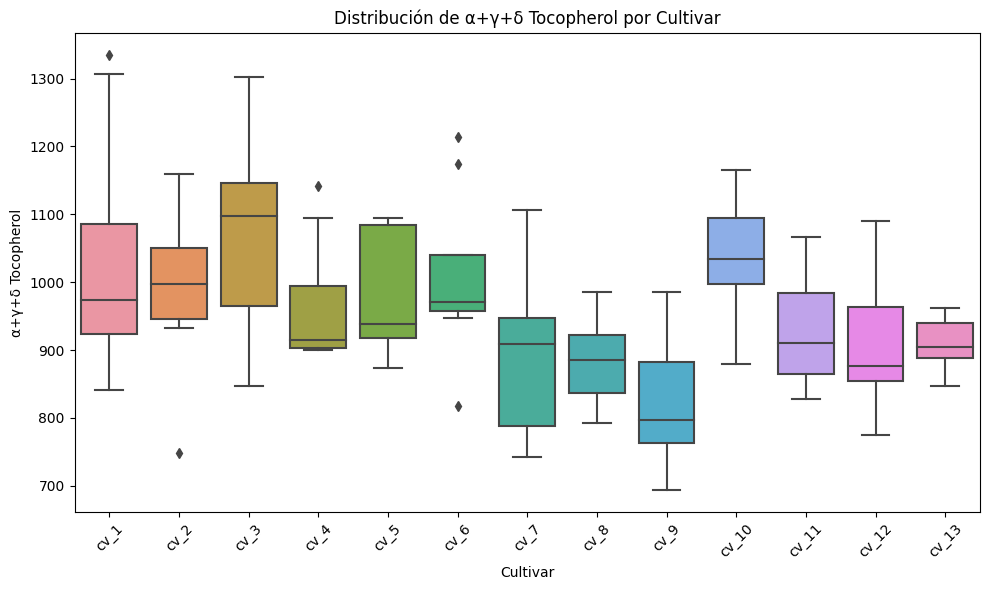

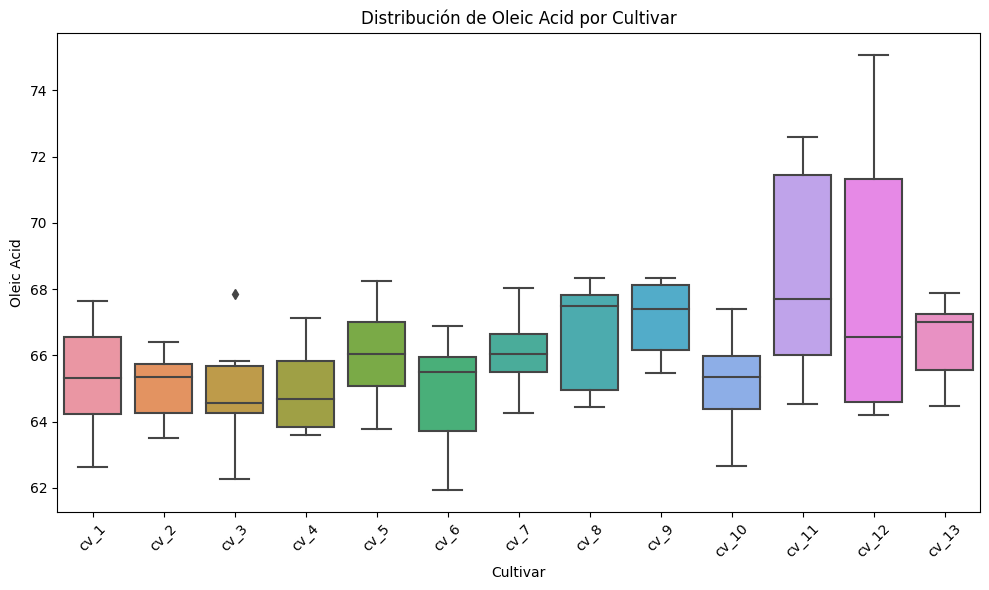

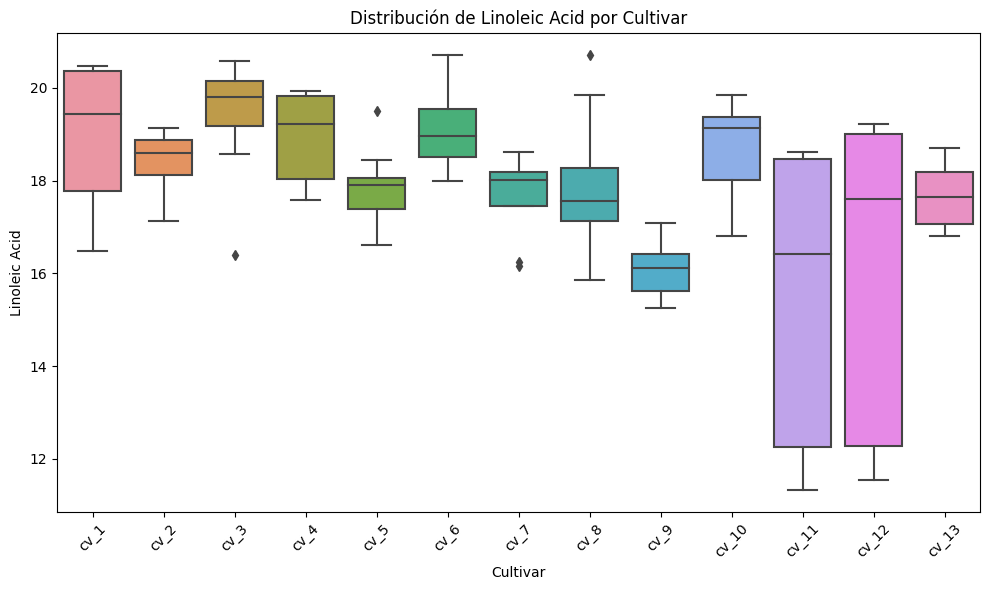

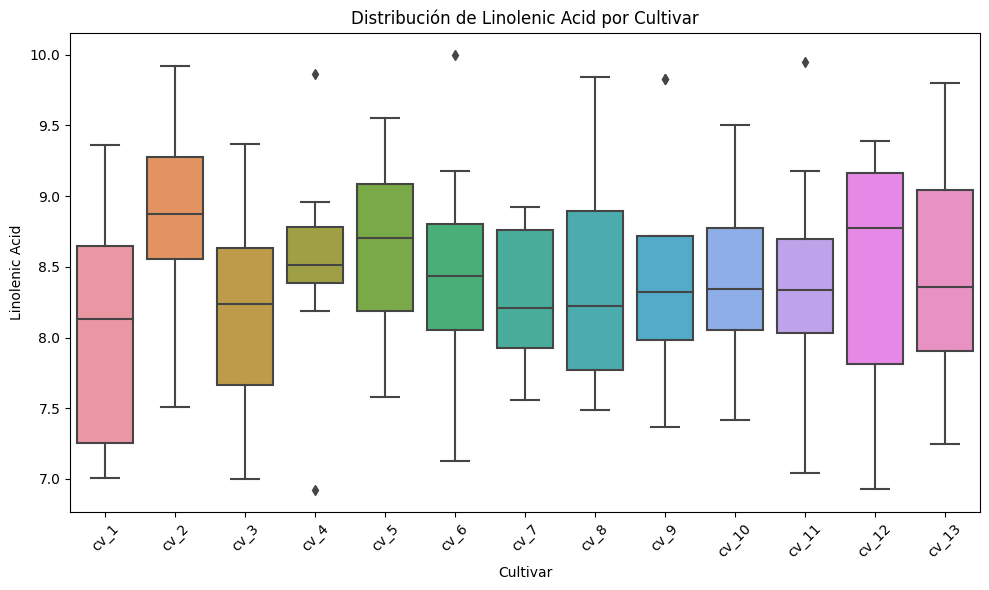

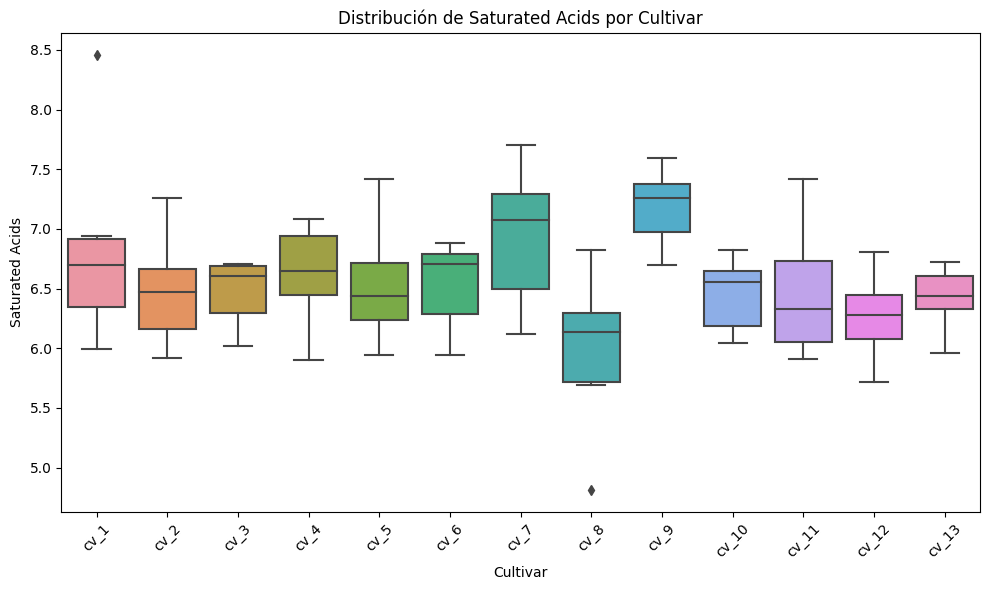

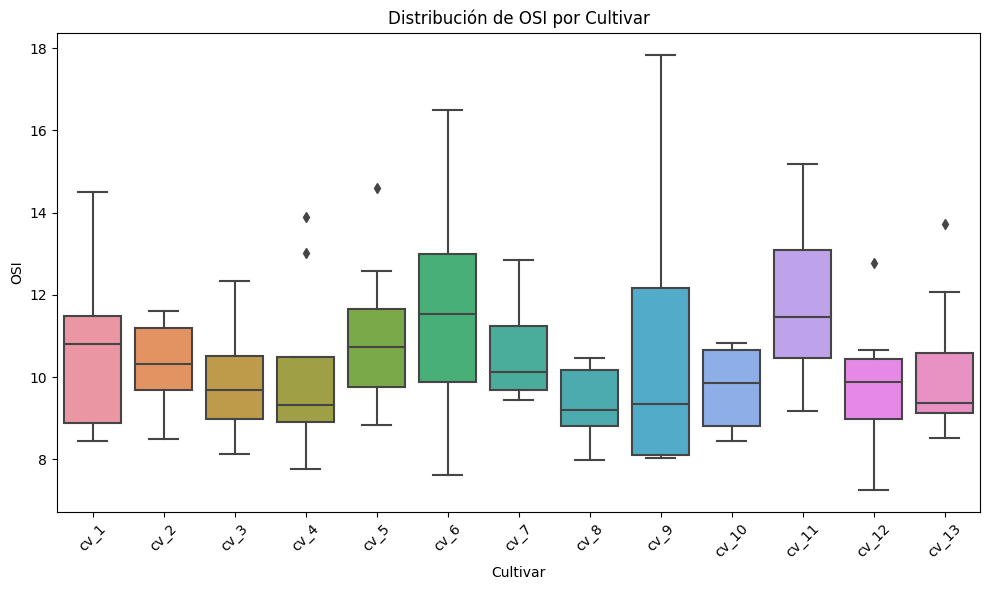

In [6]:
df_2_numeric = ['α+γ+δ Tocopherol','Oleic Acid', 'Linoleic Acid', 'Linolenic Acid', 'Saturated Acids', 'OSI']

for col in df_2_numeric:
    plot_column_distribution(df_2, col)

In [7]:
df_2_copy = df_2.drop(['Repetición', 'α Tocopherol', 'γ Tocopherol', 'δ Tocopherol',
                            'Palmitic Acid', 'Palmitoleic Acid', 'Stearic Acid',
                            'Arachidic Acid', 'Ecosenoic Acid'], axis = 1)
df_2_copy

,Cultivar,α+γ+δ Tocopherol,Oleic Acid,Linoleic Acid,Linolenic Acid,OSI,Saturated Acids
0,cv_1,1335.18,64.49,20.41,7.11,11.38,6.94
1,cv_1,1306.66,64.51,20.48,7.01,10.45,6.91
2,cv_2,1044.22,65.69,18.65,7.92,10.29,6.50
3,cv_2,1159.96,65.64,18.53,7.51,11.47,7.26
4,cv_3,1155.22,65.82,19.38,7.04,12.34,6.60
...,...,...,...,...,...,...,...
99,cv_11,841.38,65.94,18.62,8.10,15.17,6.23
100,cv_12,867.43,66.02,17.22,7.94,9.87,6.81
101,cv_12,957.98,71.49,12.30,8.86,10.36,6.12
102,cv_13,912.54,66.85,17.16,8.15,13.72,6.72


In [ ]:
df_2_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Cultivar               104 non-null    object 
 1   α+γ+δ Tocopherol       104 non-null    float64
 2   Oleic Acid             104 non-null    float64
 3   Linoleic Acid          104 non-null    float64
 4   Linolenic Acid         104 non-null    float64
 5   OSI                    104 non-null    float64
 6   Saturated Acids        104 non-null    float64
 7   Poliinsaturated Acids  104 non-null    float64
dtypes: float64(7), object(1)
memory usage: 6.6+ KB


In [8]:
df_2_mean = df_2.copy().groupby(['Cultivar'], as_index=False).mean(numeric_only=True)
df_2_std = df_2.copy().groupby(['Cultivar'], as_index=False).std(ddof=1)
df_2_mean = df_2_mean.drop(['Repetición', 'α Tocopherol', 'γ Tocopherol', 'δ Tocopherol',
                            'Palmitic Acid', 'Palmitoleic Acid', 'Stearic Acid',
                            'Arachidic Acid', 'Ecosenoic Acid'], axis = 1)
df_2_std

,Cultivar,Repetición,α Tocopherol,γ Tocopherol,δ Tocopherol,α+γ+δ Tocopherol,Palmitic Acid,Palmitoleic Acid,Stearic Acid,Oleic Acid,Linoleic Acid,Linolenic Acid,Arachidic Acid,Ecosenoic Acid,OSI,Saturated Acids
0,cv_1,0.534522,129.489140,61.635655,4.885126,186.476875,0.267044,0.071602,0.462601,1.768276,1.621238,0.869720,0.119754,0.399428,2.037162,0.783517
1,cv_10,0.534522,51.127691,43.671852,4.680363,89.830222,0.168353,0.020659,0.127167,1.557878,1.128089,0.738507,0.141869,0.110510,1.002973,0.287737
2,cv_11,0.534522,51.666606,50.627054,4.332599,81.880950,0.241838,0.057181,0.318108,3.173353,3.260981,0.871779,0.121155,0.070597,2.098652,0.538846
3,cv_12,0.534522,52.368722,65.572422,4.436291,98.189473,0.119276,0.021381,0.224400,4.063331,3.427530,0.909411,0.138873,0.353139,1.620736,0.339664
4,cv_13,0.534522,44.006989,38.768561,1.965738,38.220610,0.165249,0.053835,0.159816,1.321670,0.698284,0.910114,0.150375,0.199172,1.803718,0.250225
5,cv_2,0.534522,64.612581,61.462899,5.522494,121.028581,0.249768,0.011952,0.169869,1.080680,0.763234,0.846251,0.173488,0.141421,1.141290,0.431821
6,cv_3,0.534522,113.412447,47.983062,4.642053,146.010778,0.194643,0.024165,0.224877,1.626062,1.364017,0.835360,0.159726,0.406850,1.387361,0.276454
7,cv_4,0.534522,70.161319,52.429483,5.516083,96.181082,0.231328,0.023867,0.285704,1.328896,0.987999,0.820191,0.308635,0.144265,2.217019,0.386551
8,cv_5,0.534522,54.924531,101.324669,1.680823,93.739865,0.348094,0.029641,0.184850,1.530898,0.926243,0.742871,0.153320,0.121530,1.856529,0.521755
9,cv_6,0.534522,83.696529,79.591976,4.266740,128.174325,0.166562,0.027484,0.170666,1.836268,0.990653,0.917668,0.173699,0.188433,2.963591,0.341677


In [9]:
for col in df_2_mean.columns.difference(['Cultivar']):
    error_colum = f'{col}_error'
    df_2_mean[error_colum] = df_2_std[col] * 0.836

df_2_mean

,Cultivar,α+γ+δ Tocopherol,Oleic Acid,Linoleic Acid,Linolenic Acid,OSI,Saturated Acids,Linoleic Acid_error,Linolenic Acid_error,OSI_error,Oleic Acid_error,Saturated Acids_error,α+γ+δ Tocopherol_error
0,cv_1,1032.59500,65.26500,18.96125,8.06125,10.65500,6.76875,1.355355,0.727086,1.703067,1.478279,0.655020,155.894667
1,cv_10,1037.77375,65.14125,18.65125,8.40250,9.72875,6.45750,0.943082,0.617392,0.838486,1.302386,0.240549,75.098065
2,cv_11,924.85000,68.51625,15.50625,8.41375,11.80625,6.47125,2.726180,0.728807,1.754473,2.652923,0.450476,68.452474
3,cv_12,907.12000,68.03625,16.06750,8.45000,9.80875,6.26000,2.865415,0.760268,1.354935,3.396944,0.283959,82.086400
4,cv_13,909.85875,66.43125,17.64500,8.47250,10.15625,6.42875,0.583765,0.760855,1.507908,1.104916,0.209188,31.952430
5,cv_2,987.35625,65.03875,18.38125,8.85625,10.27000,6.46875,0.638064,0.707466,0.954118,0.903449,0.361003,101.179893
6,cv_3,1067.72375,64.88250,19.37375,8.14375,9.84000,6.47375,1.140318,0.698361,1.159834,1.359388,0.231116,122.065011
7,cv_4,966.59500,64.96250,18.93375,8.51625,10.04000,6.62750,0.825967,0.685679,1.853428,1.110957,0.323156,80.407385
8,cv_5,978.47625,66.02250,17.82875,8.63500,11.01875,6.56500,0.774339,0.621040,1.552058,1.279831,0.436187,78.366527
9,cv_6,1006.26375,64.79750,19.16250,8.44000,11.70125,6.55500,0.828186,0.767170,2.477562,1.535120,0.285642,107.153736


In [ ]:
df_2_mean.columns

Index(['Cultivar', 'α+γ+δ Tocopherol', 'Oleic Acid', 'Linoleic Acid',
       'Linolenic Acid', 'OSI', 'Saturated Acids', 'Poliinsaturated Acids',
       'Linoleic Acid_error', 'Linolenic Acid_error', 'OSI_error',
       'Oleic Acid_error', 'Poliinsaturated Acids_error',
       'Saturated Acids_error', 'α+γ+δ Tocopherol_error'],
      dtype='object')

<Figure size 1000x600 with 0 Axes>

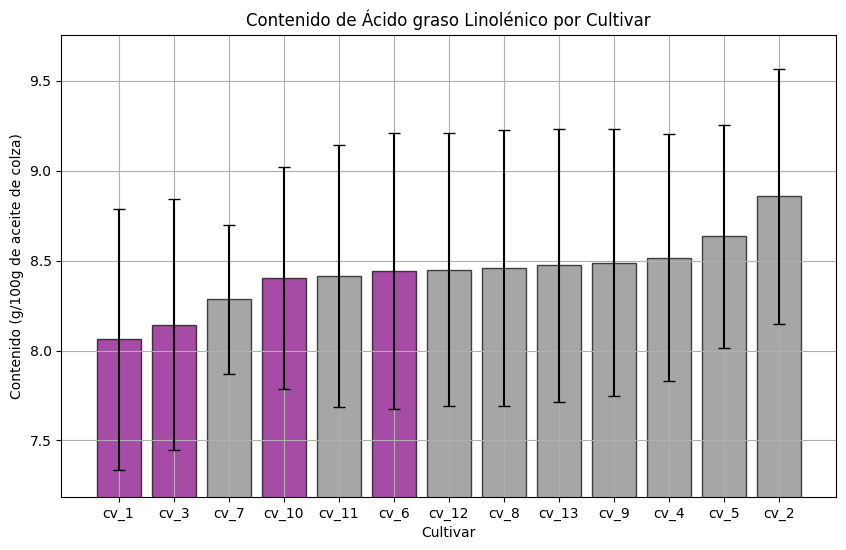

In [61]:
import matplotlib.patches as mpatches  # Importa mpatches para crear recuadros de leyenda

# Definir las columnas de interés y sus respectivos errores
columns = [
    #'α+γ+δ Tocopherol',
    #'Oleic Acid',
    #'Linoleic Acid',
    'Linolenic Acid',
    #'OSI',
    #'Saturated Acids'
    ]

error_columns = [
    #'α+γ+δ Tocopherol_error',
    #'Oleic Acid_error',
    #'Linoleic Acid_error',
    'Linolenic Acid_error',
    #'OSI_error',
    #'Saturated Acids_error'
    ]

down = ['cv_1', 'cv_3', 'cv_6', 'cv_10']
#up = ['cv_9', 'cv_7', 'cv_1']

# Crear la gráfica
plt.figure(figsize=(10, 6))

for col, err_col in zip(columns, error_columns):

    df_2_mean = df_2_mean.sort_values(by=col)

    plt.figure(figsize=(10, 6))
    x = df_2_mean['Cultivar']
    x_ticks = range(len(x))
    y = df_2_mean[col]

    error = df_2_mean[err_col]  # Doble del error para el intervalo
    y_upper_limit = max(y + error) * 1.02
    y_lower_limit = min(y - error) * 0.98

    # Crear una lista de colores basada en si el cultivar está en cult_selected
    colors = ['gray' if cultivar not in down# + up
              #else 'green' if cultivar in down
              else 'purple' for cultivar in x
              ]

    plt.bar(x_ticks, y, yerr=error, label=col, edgecolor='black', capsize=4, alpha=0.7, color=colors)

    plt.xlabel('Cultivar')
    plt.ylabel('Contenido (g/100g de aceite de colza)')
    plt.title(f'Contenido de Ácido graso Linolénico por Cultivar')
    plt.xticks(x_ticks, x)

    plt.ylim(y_lower_limit, y_upper_limit)

    legend_labels = {}

    ## Crear leyendas personalizadas para los grupos (excluyendo el color "gray")
    for color in set(colors) - {'gray'}:
        legend_labels[color] = {
            #'green': 'Valores Bajos',
            'orange': 'Valores Altos'
        }.get(color, 'Otro')

    # Crear una lista de objetos de leyenda con recuadros pintados
    legend_handles = [mpatches.Patch(color=color, label=legend_labels[color]) for color in set(colors) - {'gray'}]

    # Agregar la leyenda al gráfico
    #plt.legend(handles=legend_handles)

    plt.grid(True)
    plt.show()

In [ ]:
df_2_mean.columns

Index(['Cultivar', 'α+γ+δ Tocopherol', 'Oleic Acid', 'Linoleic Acid',
       'Linolenic Acid', 'OSI', 'Saturated Acids', 'Poliinsaturated Acids',
       'Linoleic Acid_error', 'Linolenic Acid_error', 'OSI_error',
       'Oleic Acid_error', 'Poliinsaturated Acids_error',
       'Saturated Acids_error', 'α+γ+δ Tocopherol_error'],
      dtype='object')

In [11]:
import scipy.stats as stats

# Ácidos grasos para analizar
acids = ['α+γ+δ Tocopherol', 'Oleic Acid', 'Linoleic Acid', 'Linolenic Acid', 'OSI', 'Saturated Acids']

# Realizar análisis de varianza (ANOVA) para cada ácido graso
for acid in acids:
    print(f'Análisis de Varianza (ANOVA) para {acid}:')

    # Realizar el ANOVA
    model = stats.f_oneway(*[group[acid] for name, group in df_2_copy.groupby('Cultivar')])

    # Imprimir resultados
    print('Estadísticas F:', model.statistic)
    print('Valor p:', model.pvalue)

    if model.pvalue < 0.05:
        print('Hay diferencia significativa entre Cultivar\n')
    else:
        print('No hay diferencia significativa entre Cultivar\n')


Análisis de Varianza (ANOVA) para α+γ+δ Tocopherol:
Estadísticas F: 3.4266397932563493
Valor p: 0.0003602563144678003
Hay diferencia significativa entre Cultivar

Análisis de Varianza (ANOVA) para Oleic Acid:
Estadísticas F: 3.1225159874104973
Valor p: 0.0009562818203023726
Hay diferencia significativa entre Cultivar

Análisis de Varianza (ANOVA) para Linoleic Acid:
Estadísticas F: 4.608380919969948
Valor p: 8.597722973108676e-06
Hay diferencia significativa entre Cultivar

Análisis de Varianza (ANOVA) para Linolenic Acid:
Estadísticas F: 0.4558542048142278
Valor p: 0.934931260344615
No hay diferencia significativa entre Cultivar

Análisis de Varianza (ANOVA) para OSI:
Estadísticas F: 1.1436914344358393
Valor p: 0.3359256892171834
No hay diferencia significativa entre Cultivar

Análisis de Varianza (ANOVA) para Saturated Acids:
Estadísticas F: 3.23133048468231
Valor p: 0.0006742458792480568
Hay diferencia significativa entre Cultivar



In [ ]:
from itertools import combinations
from scipy.stats import ttest_ind

# Columnas para comparar
columns_to_compare = ['OSI', 'α+γ+δ Tocopherol', 'Oleic Acid', 'Linoleic Acid', 'Saturated Acids']  # Agrega las demás columnas

for col in columns_to_compare:
    print(f"Comparación para la columna {col}:")
    print("=" * 50)

    # Realizar todas las combinaciones posibles de comparación entre categorías
    category_combinations = combinations(df_2['Cultivar'].unique(), 2)

    for category1, category2 in category_combinations:
        values_category1 = df_2[df_2['Cultivar'] == category1][col]
        values_category2 = df_2[df_2['Cultivar'] == category2][col]

        # Calcular la prueba t de Student
        t_statistic, p_value = ttest_ind(values_category1, values_category2, equal_var=False)

        if p_value < 0.05:
            print(f"Hay diferencia significativa entre {category1} y {category2}.")

    print("=" * 50)


Comparación para la columna OSI:
Hay diferencia significativa entre cv_3 y cv_11.
Hay diferencia significativa entre cv_5 y cv_8.
Hay diferencia significativa entre cv_7 y cv_8.
Hay diferencia significativa entre cv_8 y cv_11.
Hay diferencia significativa entre cv_10 y cv_11.
Comparación para la columna α+γ+δ Tocopherol:
Hay diferencia significativa entre cv_1 y cv_9.
Hay diferencia significativa entre cv_2 y cv_9.
Hay diferencia significativa entre cv_3 y cv_7.
Hay diferencia significativa entre cv_3 y cv_8.
Hay diferencia significativa entre cv_3 y cv_9.
Hay diferencia significativa entre cv_3 y cv_11.
Hay diferencia significativa entre cv_3 y cv_12.
Hay diferencia significativa entre cv_3 y cv_13.
Hay diferencia significativa entre cv_4 y cv_9.
Hay diferencia significativa entre cv_5 y cv_8.
Hay diferencia significativa entre cv_5 y cv_9.
Hay diferencia significativa entre cv_6 y cv_8.
Hay diferencia significativa entre cv_6 y cv_9.
Hay diferencia significativa entre cv_7 y cv_10.
H

In [ ]:
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison

# Columnas para comparar
columns_to_compare = ['α+γ+δ Tocopherol', 'OSI', 'Oleic Acid', 'Linoleic Acid', 'Saturated Acids']  # Agrega las demás columnas

for col in columns_to_compare:
    groups = df_2['Cultivar'].unique()
    data = {group: df_2[df_2['Cultivar'] == group][col] for group in groups}

    f_statistic, p_value = f_oneway(*data.values())

    mc = MultiComparison(df_2[col], df_2['Cultivar'])
    result = mc.tukeyhsd()
    print(f'\n\nresultados para la columna {col}')
    print(result)



resultados para la columna α+γ+δ Tocopherol
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
  cv_1  cv_10    5.1788    1.0 -184.1832 194.5407  False
  cv_1  cv_11  -107.745 0.7698 -297.1069  81.6169  False
  cv_1  cv_12  -125.475 0.5552 -314.8369  63.8869  False
  cv_1  cv_13 -122.7363   0.59 -312.0982  66.6257  False
  cv_1   cv_2  -45.2387 0.9998 -234.6007 144.1232  False
  cv_1   cv_3   35.1288    1.0 -154.2332 224.4907  False
  cv_1   cv_4     -66.0 0.9928 -255.3619 123.3619  False
  cv_1   cv_5  -54.1188 0.9989 -243.4807 135.2432  False
  cv_1   cv_6  -26.3312    1.0 -215.6932 163.0307  False
  cv_1   cv_7  -142.435 0.3501 -331.7969  46.9269  False
  cv_1   cv_8   -150.14 0.2711 -339.5019  39.2219  False
  cv_1   cv_9   -215.58  0.012 -404.9419 -26.2181   True
 cv_10  cv_11 -112.9237 0.7112 -302.2857  76.4382  False
 cv_10  cv_12 -130.6538 0.4897 -320.0157  

In [12]:
import pandas as pd
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison

# Columnas para comparar
columns_to_compare = ['α+γ+δ Tocopherol', 'Oleic Acid', 'Linoleic Acid', 'Saturated Acids', 'OSI', 'Linolenic Acid']  # Agrega las demás columnas

for col in columns_to_compare:
    groups = df_2['Cultivar'].unique()
    data = {group: df_2[df_2['Cultivar'] == group][col] for group in groups}

    f_statistic, p_value = f_oneway(*data.values())

    mc = MultiComparison(df_2[col], df_2['Cultivar'])
    result = mc.tukeyhsd()

    # Convierte el resultado a DataFrame
    result_df = pd.DataFrame(data=result._results_table.data[1:], columns=result._results_table.data[0])

    # Ordenar las filas por los valores de p-adj
    sorted_result = result_df.sort_values(by='p-adj')

    print(f'\n\nresultados para la columna {col}')
    print(sorted_result.head(15))




resultados para la columna α+γ+δ Tocopherol
   group1 group2  meandiff   p-adj     lower     upper  reject
62   cv_3   cv_9 -250.7088  0.0013 -440.0707  -61.3468    True
22  cv_10   cv_9 -220.7588  0.0088 -410.1207  -31.3968    True
11   cv_1   cv_9 -215.5800  0.0120 -404.9419  -26.2181    True
74   cv_6   cv_9 -189.2488  0.0503 -378.6107    0.1132   False
61   cv_3   cv_8 -185.2688  0.0613 -374.6307    4.0932   False
60   cv_3   cv_7 -177.5638  0.0885 -366.9257   11.7982   False
56   cv_2   cv_9 -170.3413  0.1224 -359.7032   19.0207   False
71   cv_5   cv_9 -161.4613  0.1774 -350.8232   27.9007   False
35  cv_12   cv_3  160.6038  0.1835  -28.7582  349.9657   False
43  cv_13   cv_3  157.8650  0.2042  -31.4969  347.2269   False
21  cv_10   cv_8 -155.3188  0.2249 -344.6807   34.0432   False
10   cv_1   cv_8 -150.1400  0.2711 -339.5019   39.2219   False
67   cv_4   cv_9 -149.5800  0.2765 -338.9419   39.7819   False
20  cv_10   cv_7 -147.6138  0.2957 -336.9757   41.7482   False
26  cv_11

In [ ]:
df_2_mean.columns

Index(['Cultivar', 'α+γ+δ Tocopherol', 'Oleic Acid', 'Linoleic Acid',
       'Linolenic Acid', 'OSI', 'Saturated Acids', 'Poliinsaturated Acids',
       'Linoleic Acid_error', 'Linolenic Acid_error', 'OSI_error',
       'Oleic Acid_error', 'Poliinsaturated Acids_error',
       'Saturated Acids_error', 'α+γ+δ Tocopherol_error'],
      dtype='object')

In [ ]:
from sklearn.cluster import MeanShift, KMeans
from sklearn.preprocessing import MinMaxScaler

scaled_data = MinMaxScaler().fit_transform(df_2_mean[['α+γ+δ Tocopherol', 'Oleic Acid', 'Linoleic Acid', 'Saturated Acids']])

kmeans = KMeans(n_clusters=3, random_state=0)
df_2_mean['cluster'] = kmeans.fit_predict(scaled_data)
#meanshift = MeanShift().fit(df_2_mean[['α+γ+δ Tocopherol', 'Oleic Acid', 'Linoleic Acid','Saturated Acids', 'Poliinsaturated Acids']])
#df_2_mean['cluster'] = meanshift.labels_
df_2_mean

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


,Cultivar,α+γ+δ Tocopherol,Oleic Acid,Linoleic Acid,Linolenic Acid,OSI,Saturated Acids,Poliinsaturated Acids,Linoleic Acid_error,Linolenic Acid_error,OSI_error,Oleic Acid_error,Poliinsaturated Acids_error,Saturated Acids_error,α+γ+δ Tocopherol_error,cluster
0,cv_1,1032.59500,65.26500,18.96125,8.06125,10.65500,6.76875,93.23750,1.355355,0.727086,1.703067,1.478279,0.654338,0.655020,155.894667,1
1,cv_10,1037.77375,65.14125,18.65125,8.40250,9.72875,6.45750,93.48625,0.943082,0.617392,0.838486,1.302386,0.284448,0.240549,75.098065,1
2,cv_11,924.85000,68.51625,15.50625,8.41375,11.80625,6.47125,93.52750,2.726180,0.728807,1.754473,2.652923,0.449773,0.450476,68.452474,2
3,cv_12,907.12000,68.03625,16.06750,8.45000,9.80875,6.26000,93.74625,2.865415,0.760268,1.354935,3.396944,0.306318,0.283959,82.086400,2
4,cv_13,909.85875,66.43125,17.64500,8.47250,10.15625,6.42875,93.59750,0.583765,0.760855,1.507908,1.104916,0.220676,0.209188,31.952430,2
5,cv_2,987.35625,65.03875,18.38125,8.85625,10.27000,6.46875,93.54125,0.638064,0.707466,0.954118,0.903449,0.365100,0.361003,101.179893,1
6,cv_3,1067.72375,64.88250,19.37375,8.14375,9.84000,6.47375,93.52875,1.140318,0.698361,1.159834,1.359388,0.242190,0.231116,122.065011,1
7,cv_4,966.59500,64.96250,18.93375,8.51625,10.04000,6.62750,93.50125,0.825967,0.685679,1.853428,1.110957,0.349965,0.323156,80.407385,1
8,cv_5,978.47625,66.02250,17.82875,8.63500,11.01875,6.56500,93.55000,0.774339,0.621040,1.552058,1.279831,0.526936,0.436187,78.366527,1
9,cv_6,1006.26375,64.79750,19.16250,8.44000,11.70125,6.55500,93.45250,0.828186,0.767170,2.477562,1.535120,0.345841,0.285642,107.153736,1


In [ ]:
def plot_selected_bar_chart(dataframe, column_name, selected_labels):

    df_sorted = dataframe.sort_values(by=column_name, ascending=False)

    unique_values = dataframe['Cultivar'].unique()
    color_dict = {value: 'blue' if value in selected_labels else 'grey' for i, value in enumerate(unique_values)}

    error = dataframe[f'{column_name}_error']

    y_upper_limit = max(df_sorted[column_name] + error) * 1.1
    y_lower_limit = min(df_sorted[column_name] - error) * 0.9

    plt.figure(figsize=(16, 6))

    bars = plt.bar(range(len(df_sorted)),
                   df_sorted[column_name],
                   yerr=error,
                   capsize=4,
                   color=[color_dict[value] for value in df_sorted['Cultivar']])

    plt.xlabel('Cultivar')
    plt.ylabel(column_name)
    plt.title(f'Valores de {column_name} por Cultivar')

    plt.xticks(range(len(df_sorted)),[label if label in selected_labels else '' for label in df_sorted['Cultivar']], rotation=0)
    plt.ylim(y_lower_limit, y_upper_limit)
    plt.tight_layout()
    plt.show()

In [ ]:
columns_to_compare = ['α+γ+δ Tocopherol', 'Oleic Acid', 'Linoleic Acid', 'Saturated Acids', 'Linolenic Acid', 'OSI']

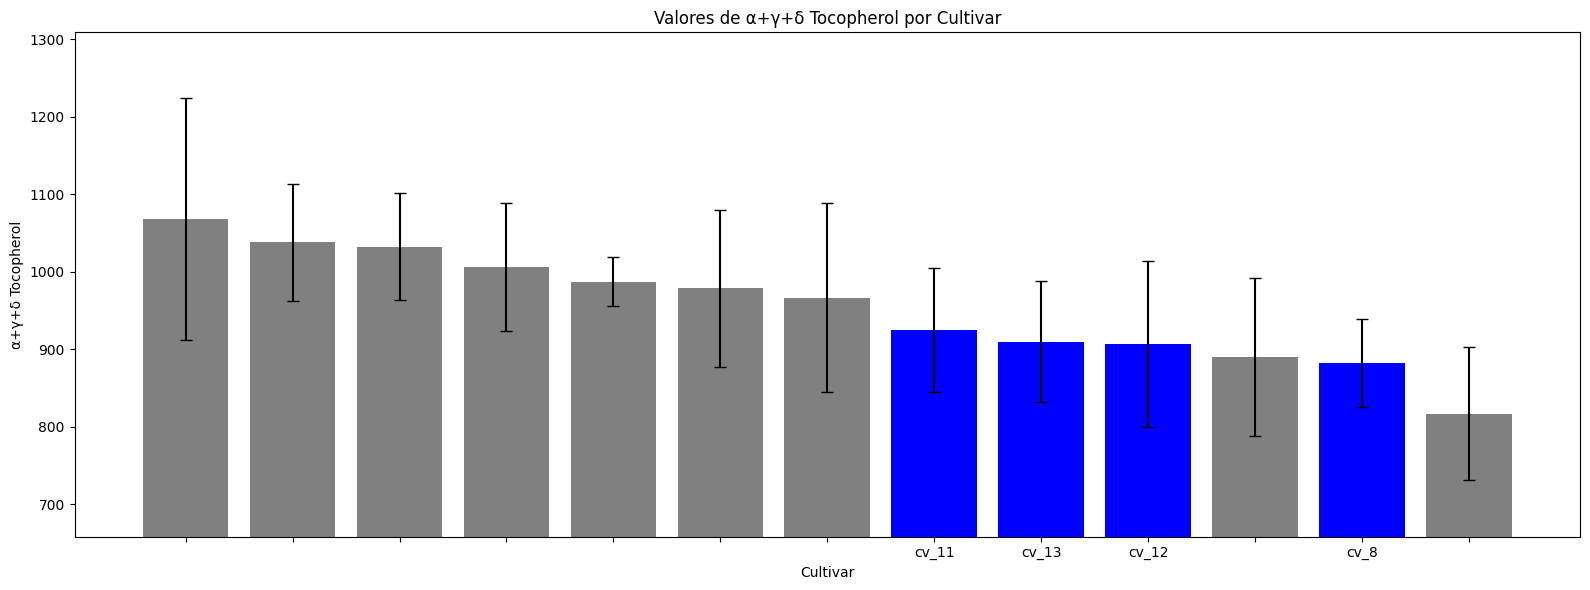

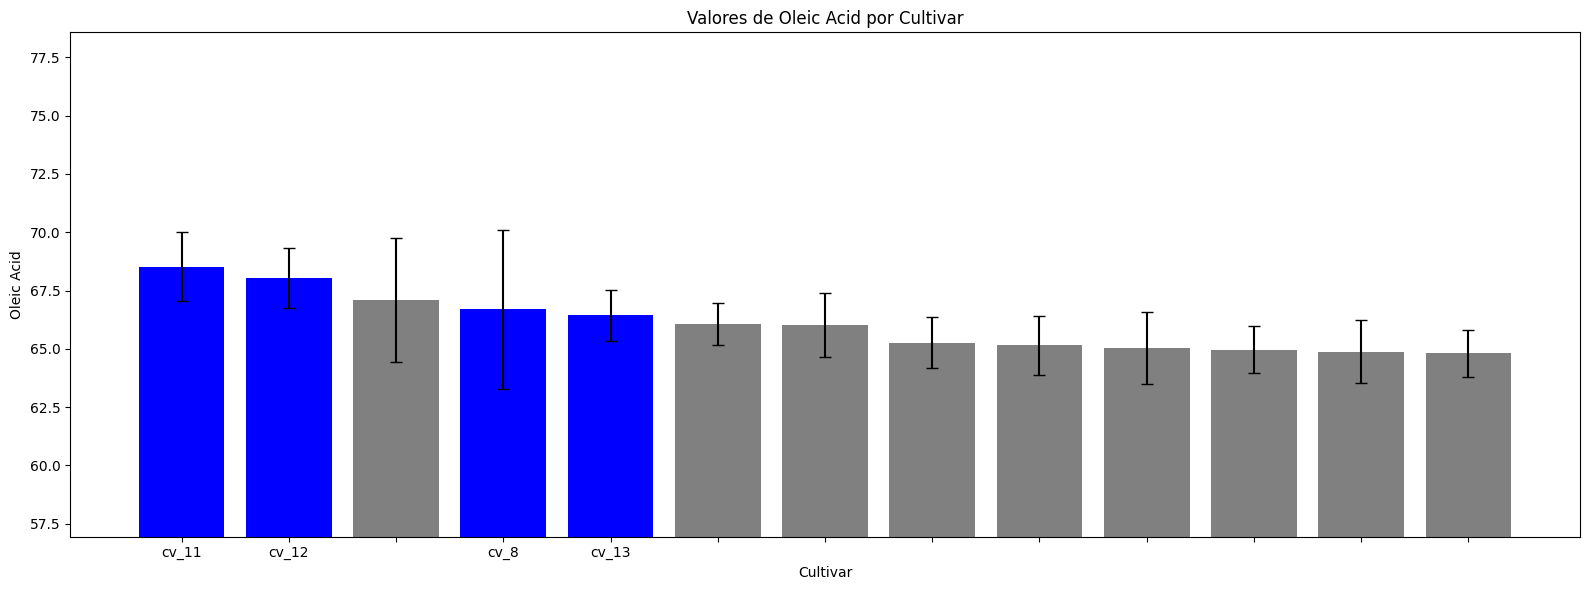

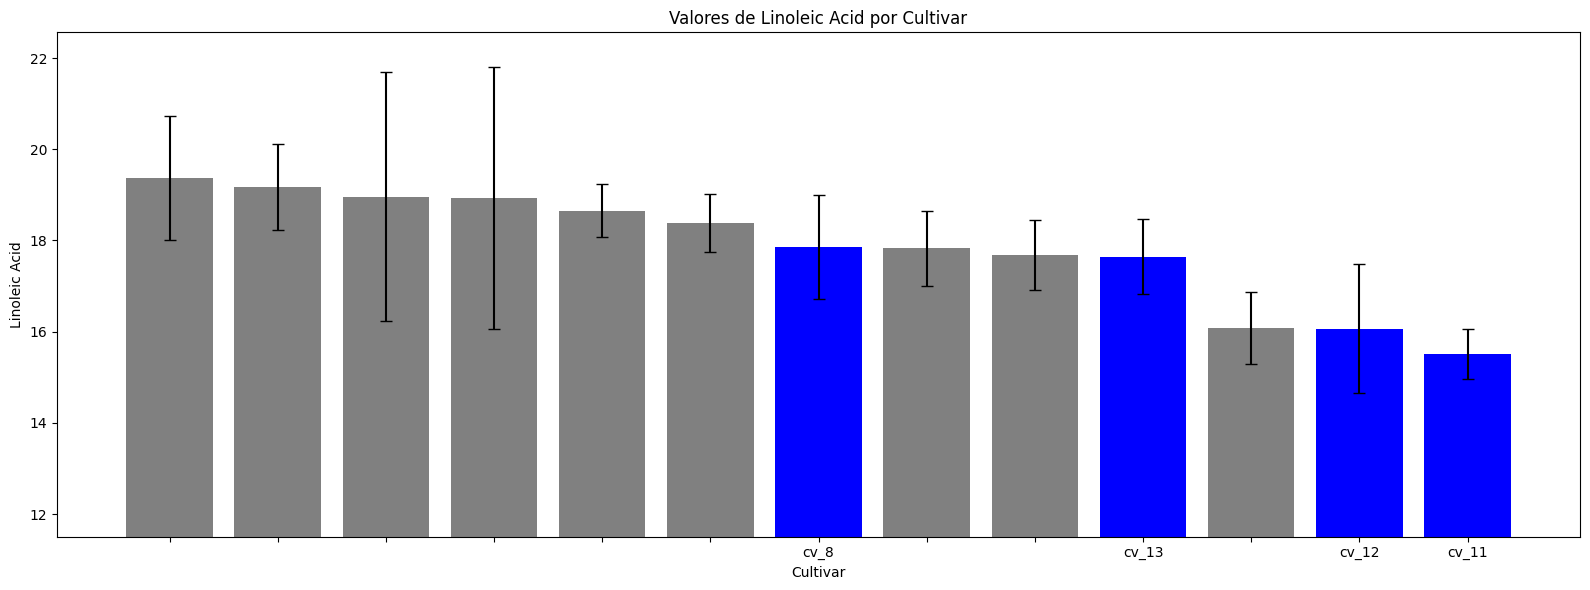

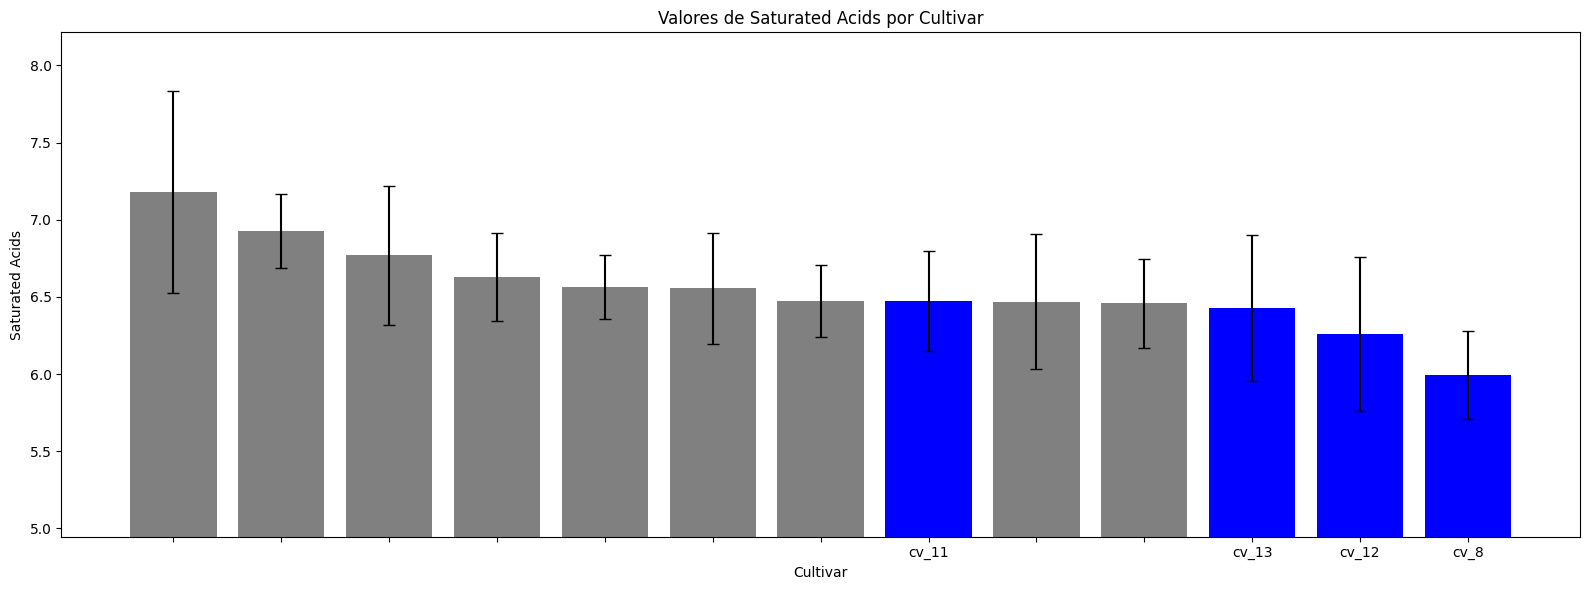

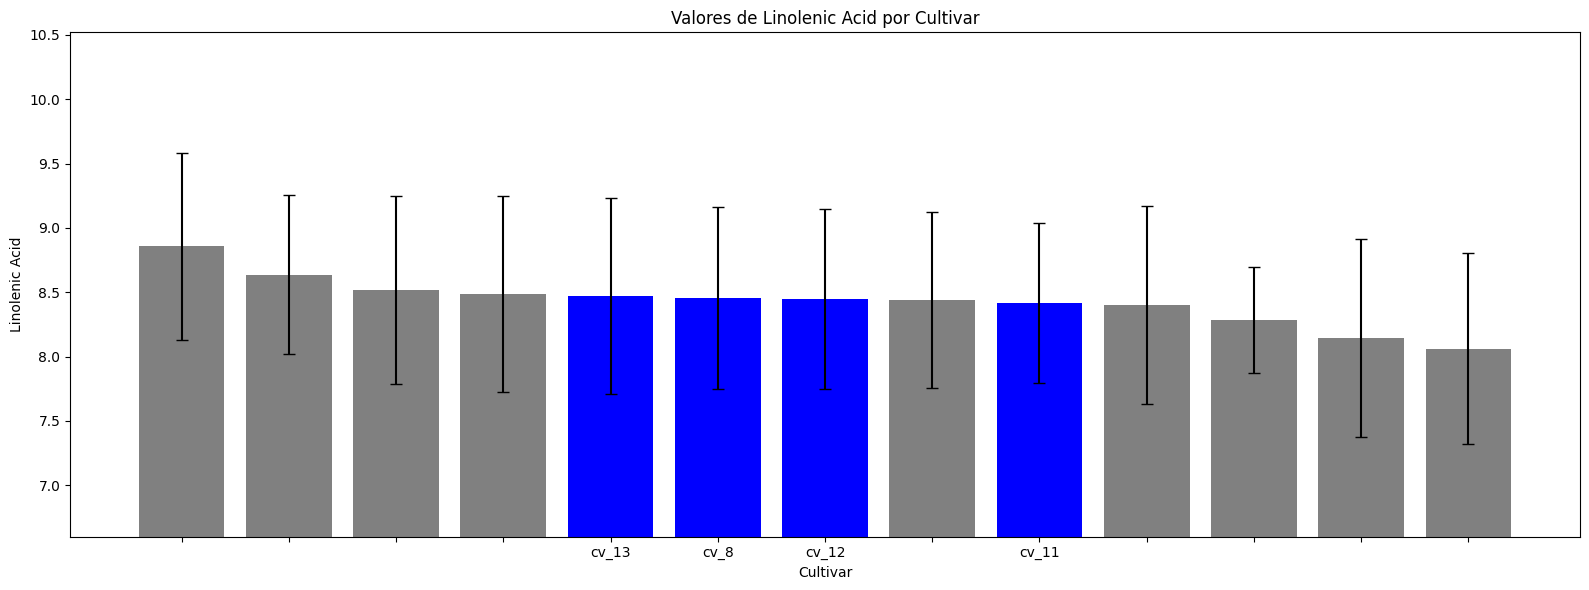

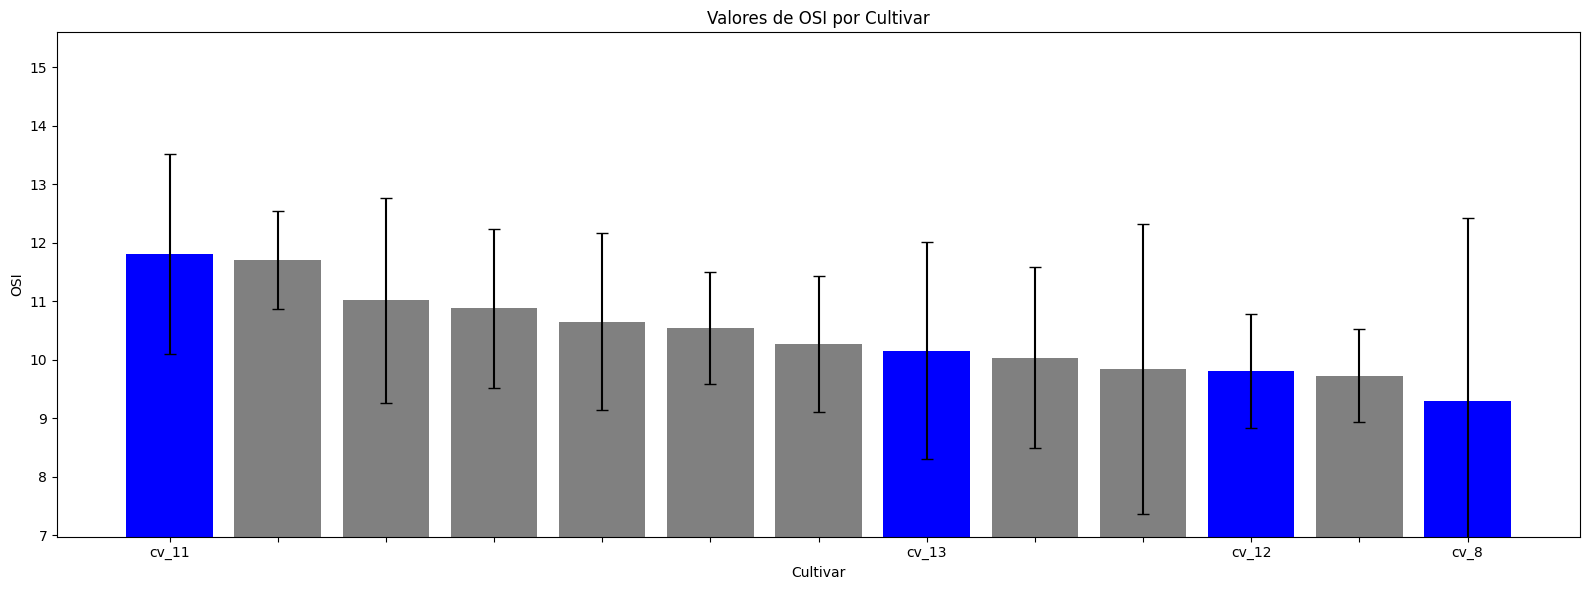

In [ ]:
for col in columns_to_compare:
    plot_selected_bar_chart(df_2_mean, col, df_2_mean[df_2_mean['cluster'] == 2]['Cultivar'].unique())

In [ ]:
def plot_intersected_bar(ax, dataframe, column_name, selected_labels):

    df_sorted = dataframe.sort_values(by=column_name, ascending=False)

    unique_values = dataframe['Cultivar'].unique()
    color_dict = {value: 'blue' if value in selected_labels else 'grey' for i, value in enumerate(unique_values)}

    error = dataframe[f'{column_name}_error']

    y_upper_limit = max(df_sorted[column_name] + error) * 1.1
    y_lower_limit = min(df_sorted[column_name] - error) * 0.75

    bars = ax.bar(range(len(df_sorted)),
                  df_sorted[column_name],
                  yerr=error,
                    capsize=4,
                  color=[color_dict[value] for value in df_sorted['Cultivar']])

    ax.set_xlabel('Cultivar')
    ax.set_ylabel(column_name)
    ax.set_title(f'Valores de {column_name} por Cultivar')

    ax.set_ylim(y_lower_limit, y_upper_limit)
    ax.set_xticks(range(len(df_sorted)))
    ax.set_xticklabels([label if label in selected_labels else '' for label in df_sorted['Cultivar']], rotation=90, fontsize=8)
    ax.grid(axis='y')

def agrupamientos(df, column_1, column_2):

    high_1 = df.sort_values(by=column_1, ascending=False).head(5)['Cultivar']#.unique()
    low_1 = df.sort_values(by=column_1, ascending=True).head(5)['Cultivar']#.unique()
    high_2 = df.sort_values(by=column_2, ascending=False).head(5)['Cultivar']#.unique()
    low_2 = df.sort_values(by=column_2, ascending=True).head(5)['Cultivar']#.unique()

    hh = np.intersect1d(high_1, high_2).tolist()
    ll = np.intersect1d(low_1, low_2).tolist()
    hl = np.intersect1d(high_1, low_2).tolist()
    lh = np.intersect1d(low_1, high_2).tolist()

    cult_groups = [hh, ll, hl, lh]

    fig, axes = plt.subplots(len(cult_groups), 2, figsize=(12, 4 * len(cult_groups)))

    for i, lis in enumerate(cult_groups):

        plot_intersected_bar(axes[i, 0], df, column_1, lis)
        plot_intersected_bar(axes[i, 1], df, column_2, lis)

    plt.tight_layout()
    plt.show()

    print("El orden en el que se retorna las listas es : \n1)high-high\n2)low-low\n3)high-low\n4)low-high")
    return hh, ll, hl, lh

In [ ]:
unique_values = df_2_copy['Cultivar'].unique()
color_palette = sns.color_palette("tab20", n_colors=len(unique_values))
color_dict = {value: color_palette[i] for i, value in enumerate(unique_values)}

In [ ]:
def plot_sorted_bar(dataframe, column_name):

    df_sorted = dataframe.sort_values(by=column_name, ascending=False)

    min_y = df_sorted[column_name].min()
    max_y = df_sorted[column_name].max()
    y_offset = 0.1 * (max_y - min_y)

    plt.figure(figsize=(16, 6))

    bars = plt.bar(range(len(df_sorted)),
                   df_sorted[column_name],
                   color=[color_dict[value] for value in df_sorted['Cultivar']]
                   )

    plt.xlabel('Cultivar')
    plt.ylabel(column_name)
    plt.title(f'Valores de {column_name} por Cultivar')

    plt.xticks(range(len(df_sorted)),
               [label for label in df_sorted['Cultivar']],
               rotation=90
               )
    plt.ylim(min_y - y_offset, max_y + y_offset)
    plt.tight_layout()
    plt.show()

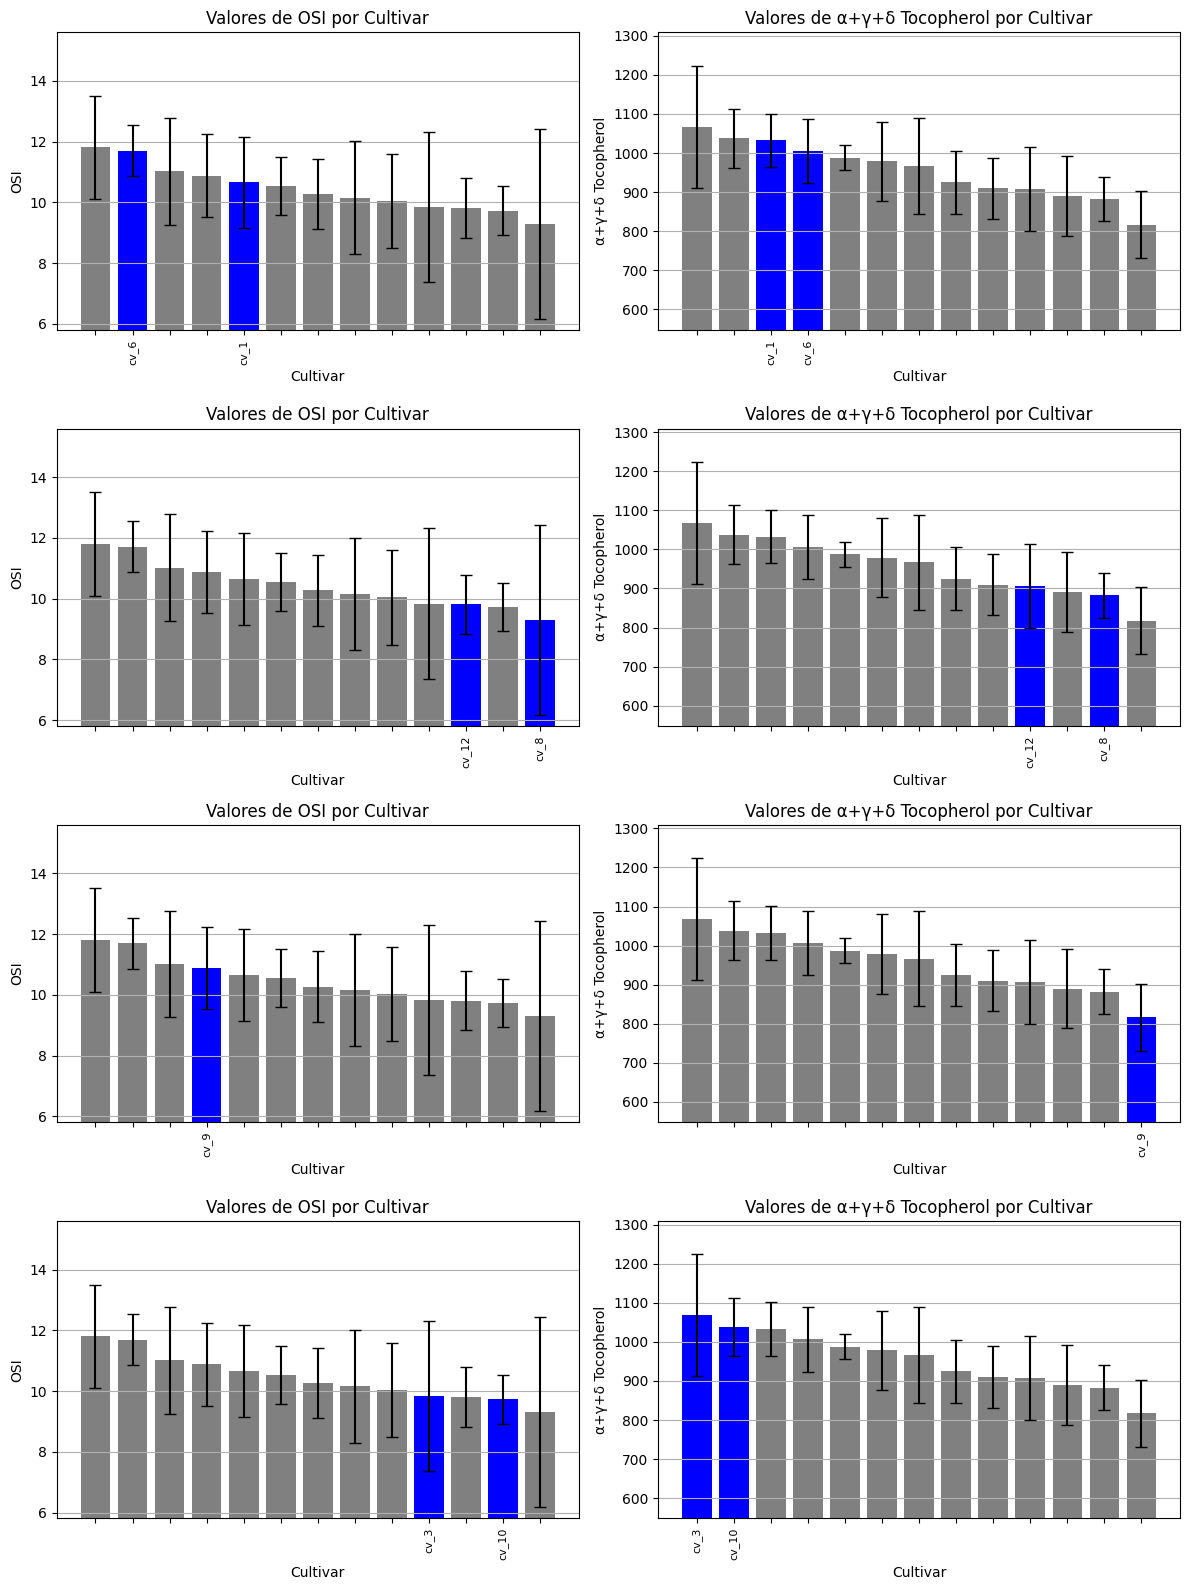

El orden en el que se retorna las listas es : 
1)high-high
2)low-low
3)high-low
4)low-high


In [ ]:
hh_osi_toco, ll_osi_toco, hl_osi_toco, lh_osi_toco = agrupamientos(df_2_mean, 'OSI', 'α+γ+δ Tocopherol')

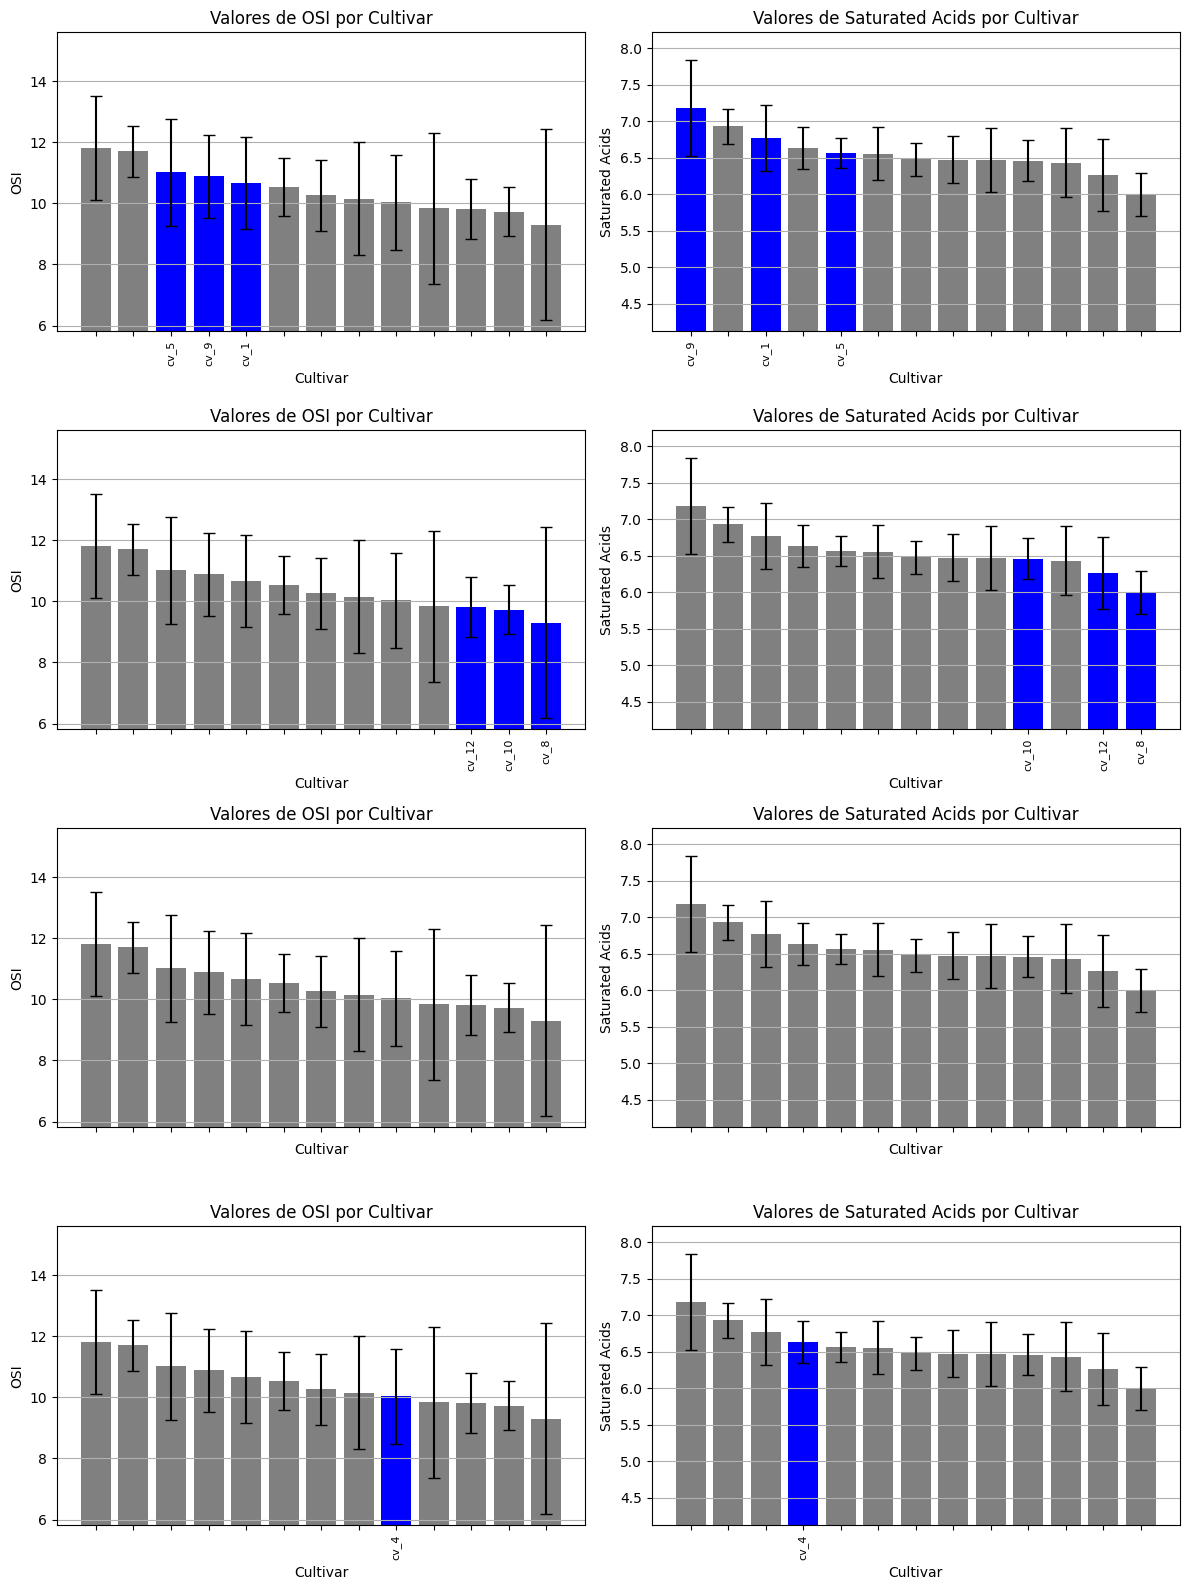

El orden en el que se retorna las listas es : 
1)high-high
2)low-low
3)high-low
4)low-high


In [ ]:
hh_osi_satu, ll_osi_satu, hl_osi_satu, lh_osi_satu = agrupamientos(df_2_mean, 'OSI', 'Saturated Acids')

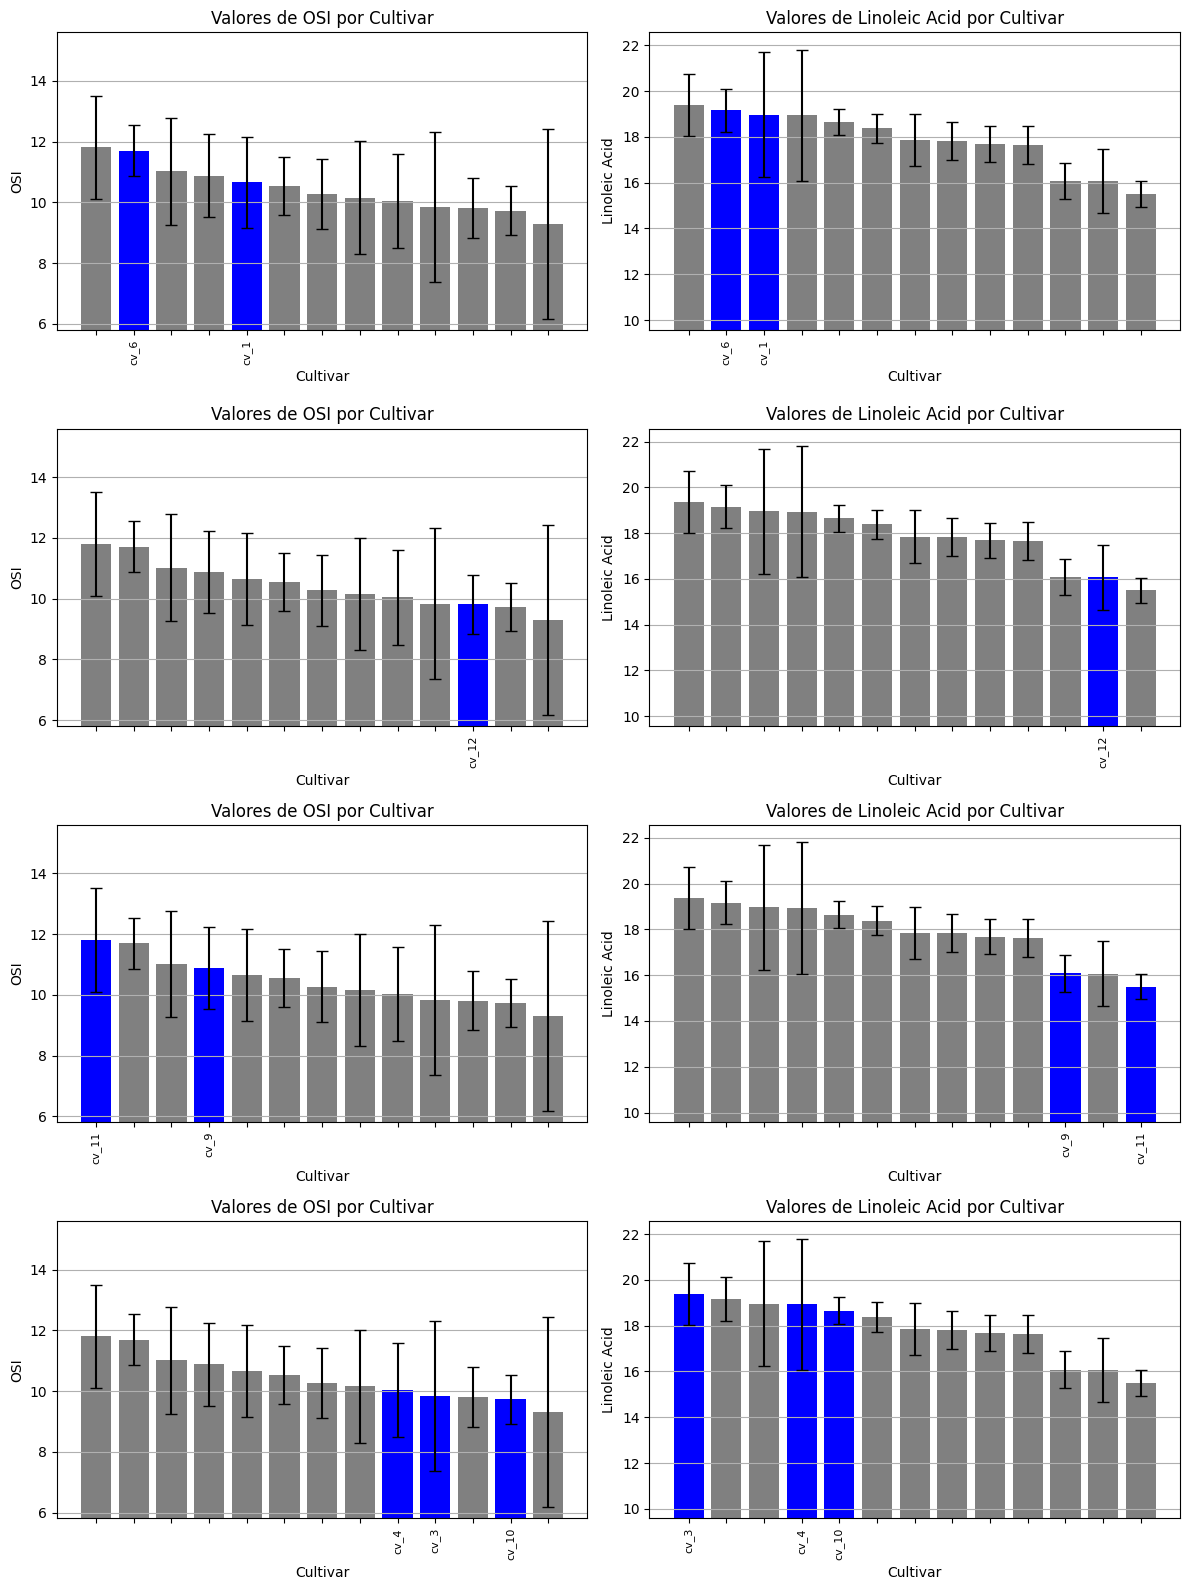

El orden en el que se retorna las listas es : 
1)high-high
2)low-low
3)high-low
4)low-high


In [ ]:
hh_osi_linoleic, ll_osi_linoleic, hl_osi_linoleic, lh_osi_linoleic = agrupamientos(df_2_mean, 'OSI', 'Linoleic Acid')

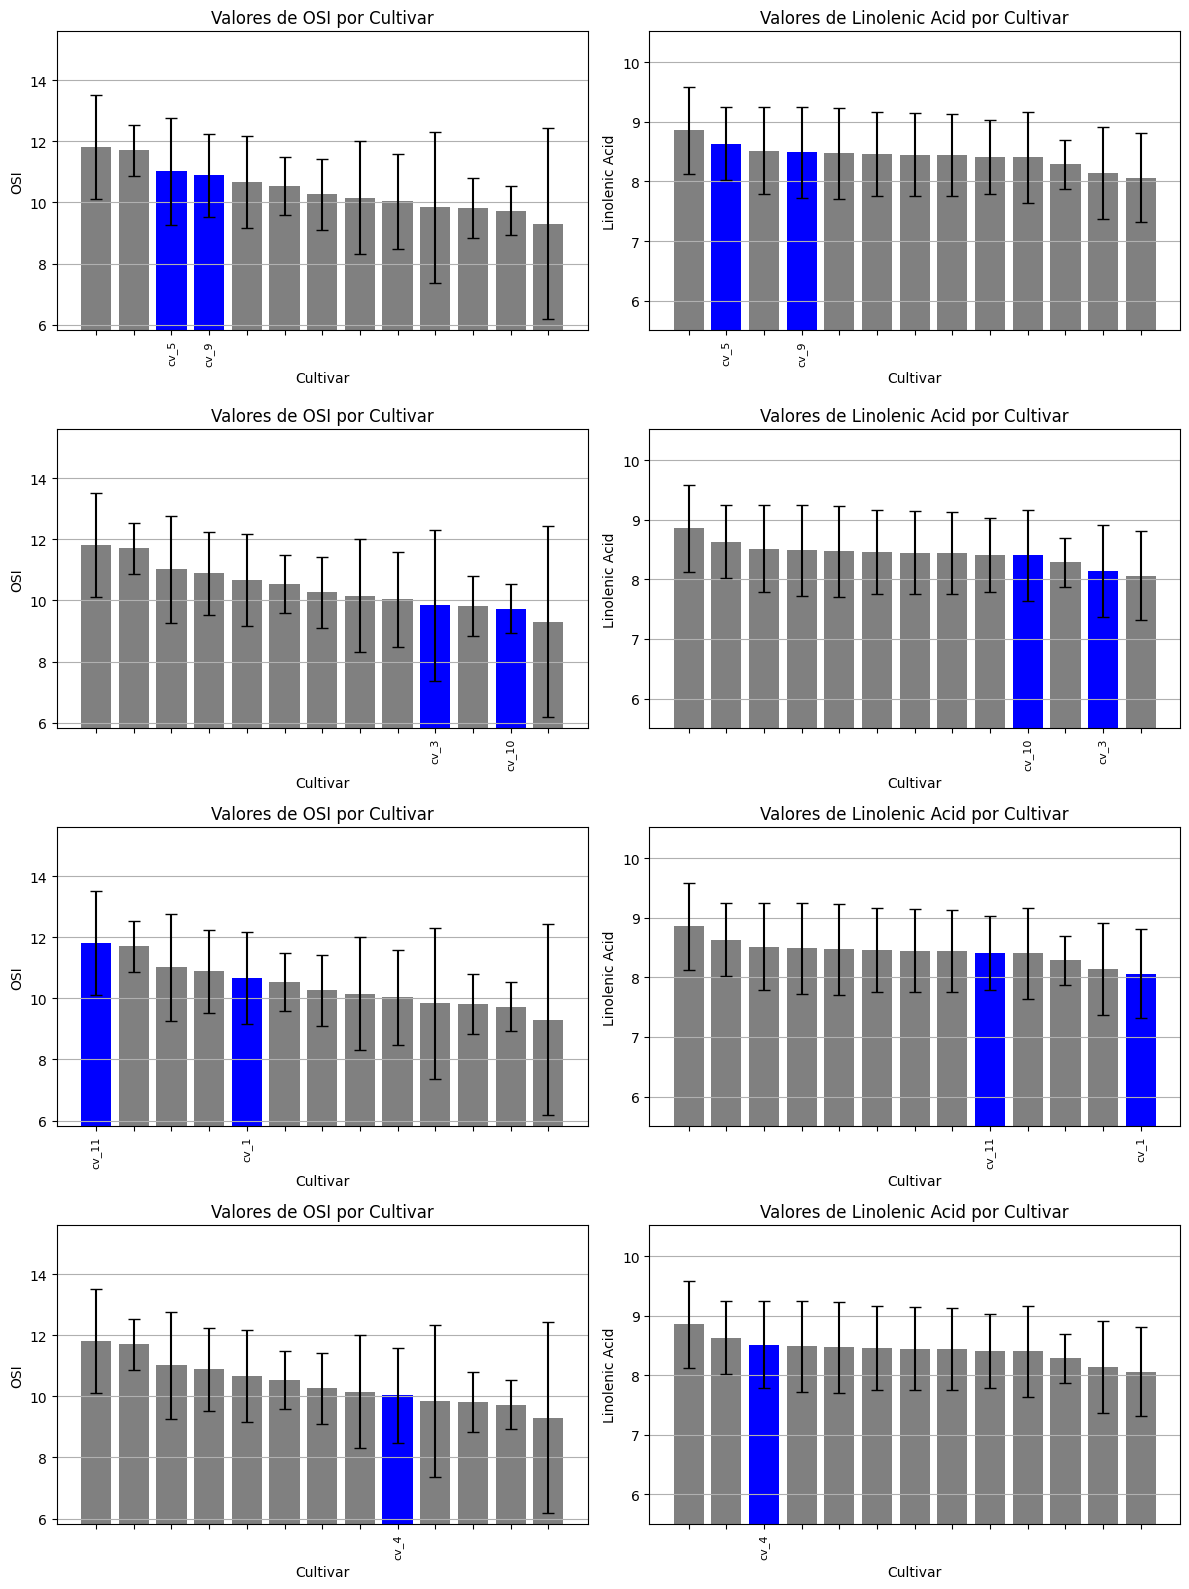

El orden en el que se retorna las listas es : 
1)high-high
2)low-low
3)high-low
4)low-high


In [ ]:
hh_osi_linolenic, ll_osi_linolenic, hl_osi_linolenic, lh_osi_linolenic = agrupamientos(df_2_mean, 'OSI', 'Linolenic Acid')

In [ ]:
def interseccion_de_listas(*listas):

    interseccion = set(listas[0])

    for lista in listas[1:]:
        interseccion = interseccion.intersection(lista)

    return list(interseccion)

In [ ]:
esperable_fuerte_1 = interseccion_de_listas(hh_osi_toco, hh_osi_satu, hl_osi_linolenic)
esperable_fuerte_1

['cv_1']

In [ ]:
esperable_fuerte_2 = interseccion_de_listas(ll_osi_toco, ll_osi_satu, lh_osi_linolenic)
esperable_fuerte_2

[]

In [ ]:
esperable_medio_1 = interseccion_de_listas(hl_osi_toco, hh_osi_satu, hl_osi_linolenic) + interseccion_de_listas(hh_osi_toco, hl_osi_satu, hl_osi_linolenic)
esperable_medio_1

[]

In [ ]:
esperable_medio_2 = interseccion_de_listas(lh_osi_toco, ll_osi_satu, lh_osi_linolenic) + interseccion_de_listas(ll_osi_toco, lh_osi_satu, lh_osi_linolenic)
esperable_medio_2

[]

In [ ]:
esperable_medio_3 = interseccion_de_listas(hh_osi_toco, hh_osi_satu, hh_osi_linolenic) + interseccion_de_listas(ll_osi_toco, ll_osi_satu, ll_osi_linolenic)
esperable_medio_3

[]

In [ ]:
esperable_debil_1 = interseccion_de_listas(lh_osi_toco, lh_osi_satu, lh_osi_linolenic) + interseccion_de_listas(lh_osi_toco, ll_osi_satu, ll_osi_linolenic) + interseccion_de_listas(ll_osi_toco, lh_osi_satu, ll_osi_linolenic)
esperable_debil_1

['cv_10']

In [ ]:
esperable_debil_2 = interseccion_de_listas(hl_osi_toco, hh_osi_satu, hh_osi_linolenic)
esperable_debil_2

['cv_9']

In [ ]:
extraños = interseccion_de_listas(hl_osi_toco, hh_osi_linolenic, hl_osi_satu) + interseccion_de_listas(lh_osi_toco, ll_osi_linolenic, lh_osi_satu)
extraños

['cv_3']

In [ ]:
def top(df, column):

    high = df.sort_values(by=column, ascending=False).head(4)['Cultivar'].unique()
    low = df.sort_values(by=column, ascending=True).head(4)['Cultivar'].unique()

    return low, high

In [ ]:
df_2_mean.columns

Index(['Cultivar', 'α+γ+δ Tocopherol', 'Oleic Acid', 'Linoleic Acid',
       'Linolenic Acid', 'OSI', 'Saturated Acids', 'Poliinsaturated Acids',
       'Linoleic Acid_error', 'Linolenic Acid_error', 'OSI_error',
       'Oleic Acid_error', 'Poliinsaturated Acids_error',
       'Saturated Acids_error', 'α+γ+δ Tocopherol_error', 'cluster'],
      dtype='object')

In [ ]:
inter_hh_osi_toco = interseccion_de_listas(top(df_2_mean, 'OSI')[1], top(df_2_mean, 'α+γ+δ Tocopherol')[1])
inter_hh_osi_toco = interseccion_de_listas(top(df_2_mean, 'OSI')[1], top(df_2_mean, 'α+γ+δ Tocopherol')[1])
inter_hh_osi_toco = interseccion_de_listas(top(df_2_mean, 'OSI')[1], top(df_2_mean, 'α+γ+δ Tocopherol')[1])
inter_hh_osi_toco = interseccion_de_listas(top(df_2_mean, 'OSI')[1], top(df_2_mean, 'α+γ+δ Tocopherol')[1])

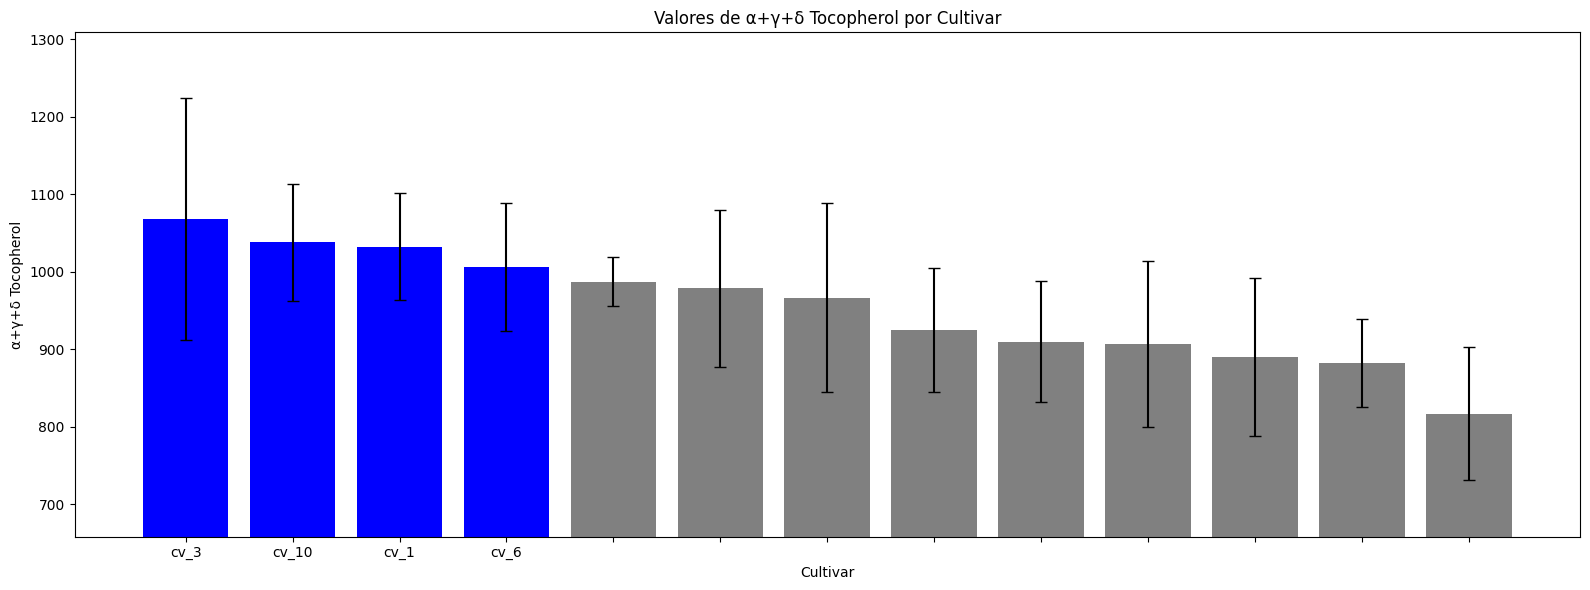

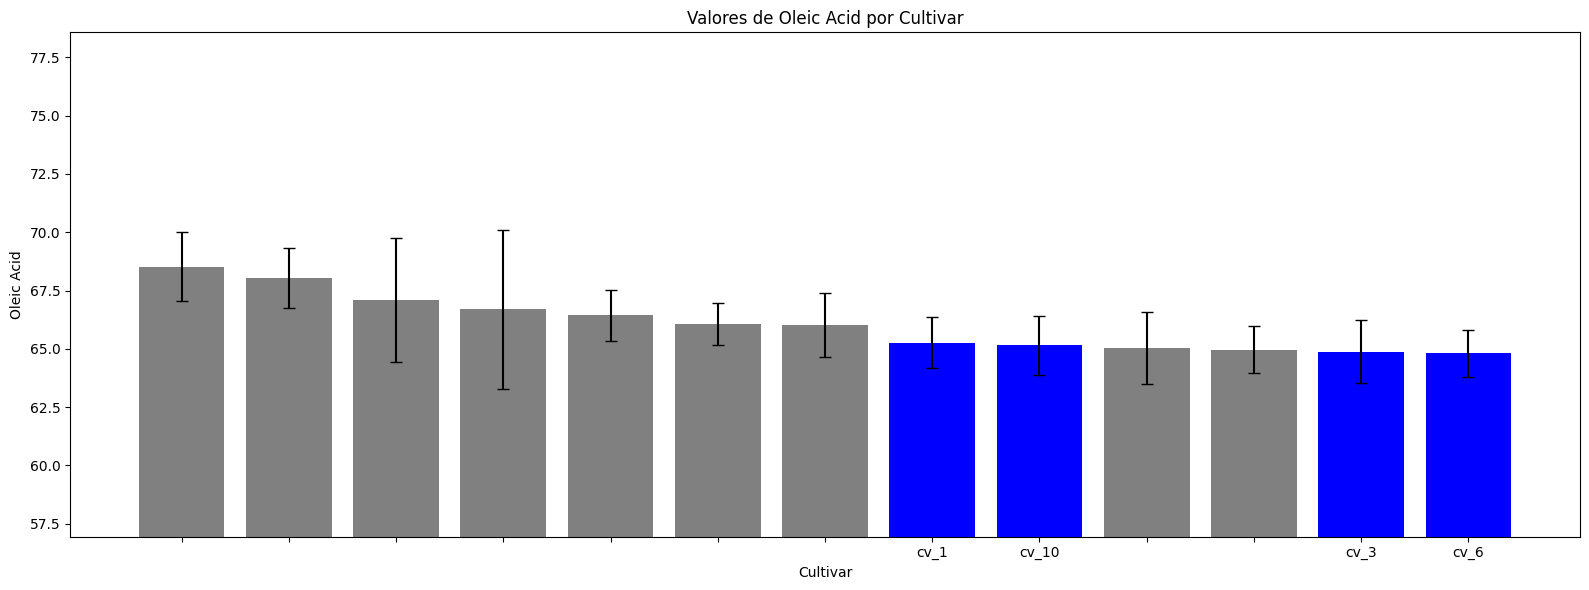

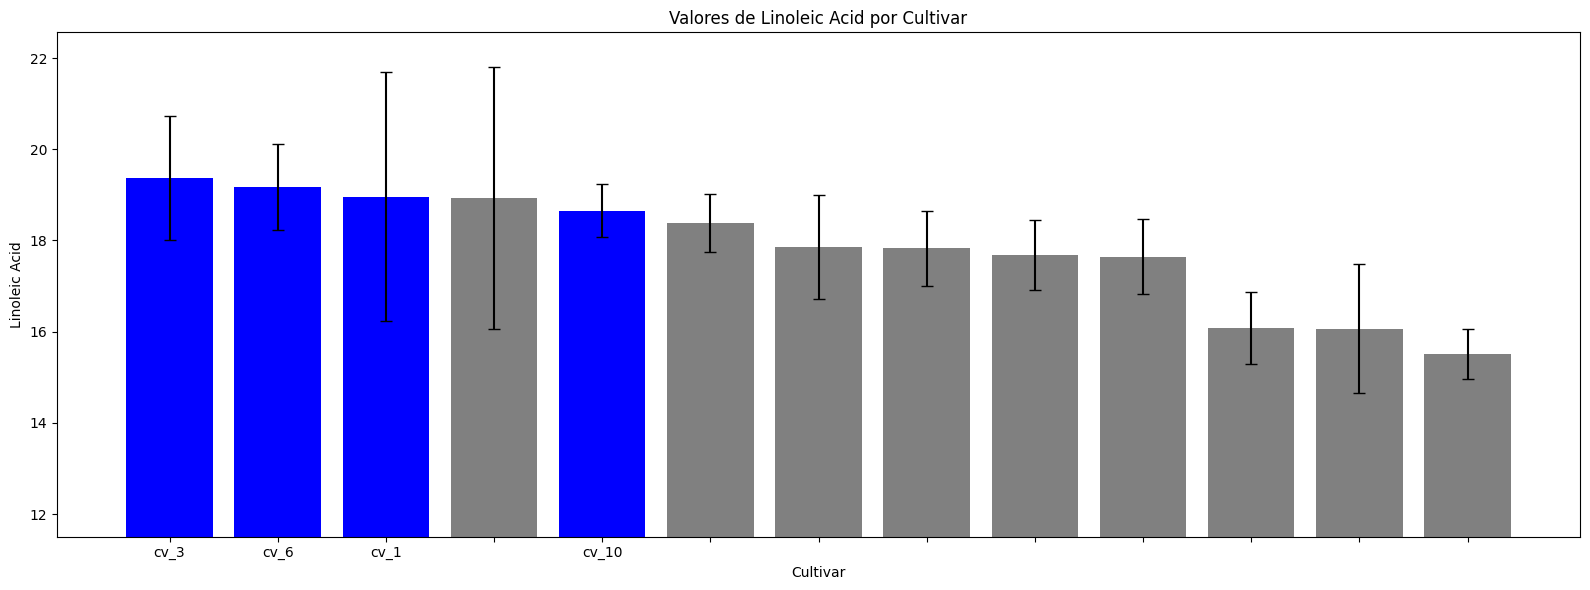

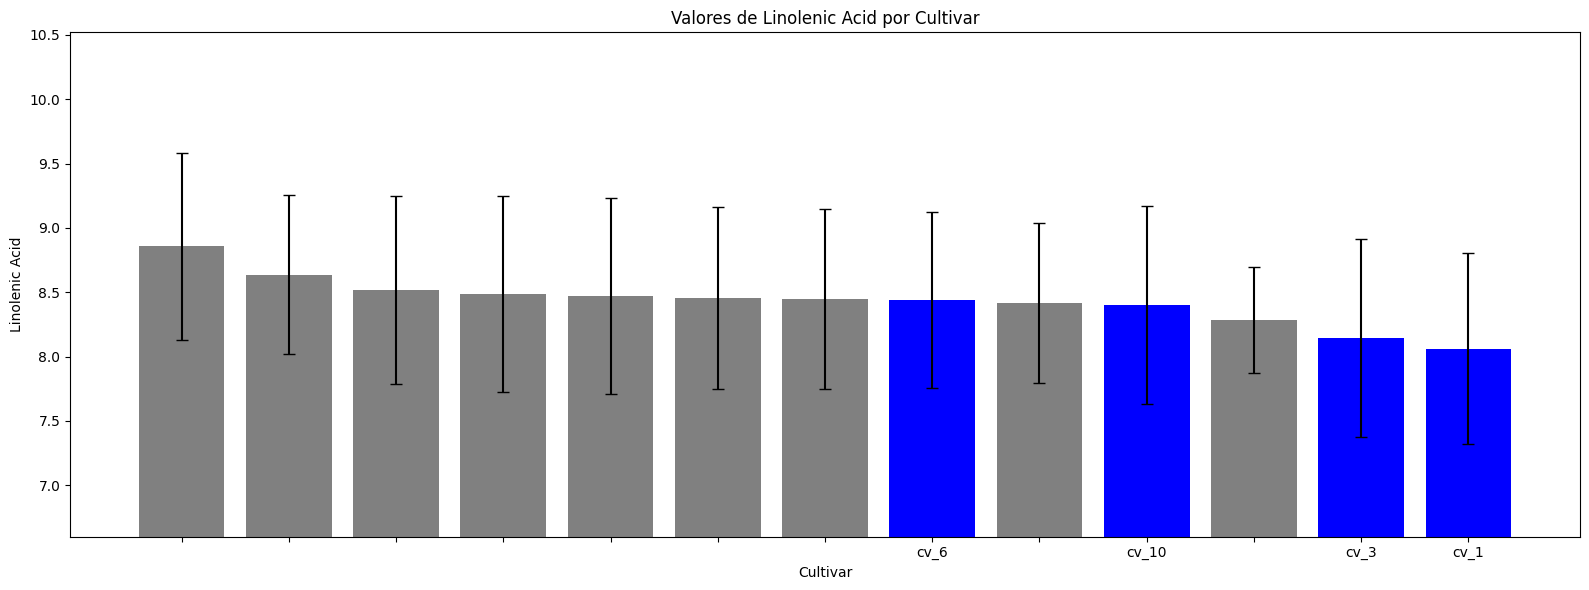

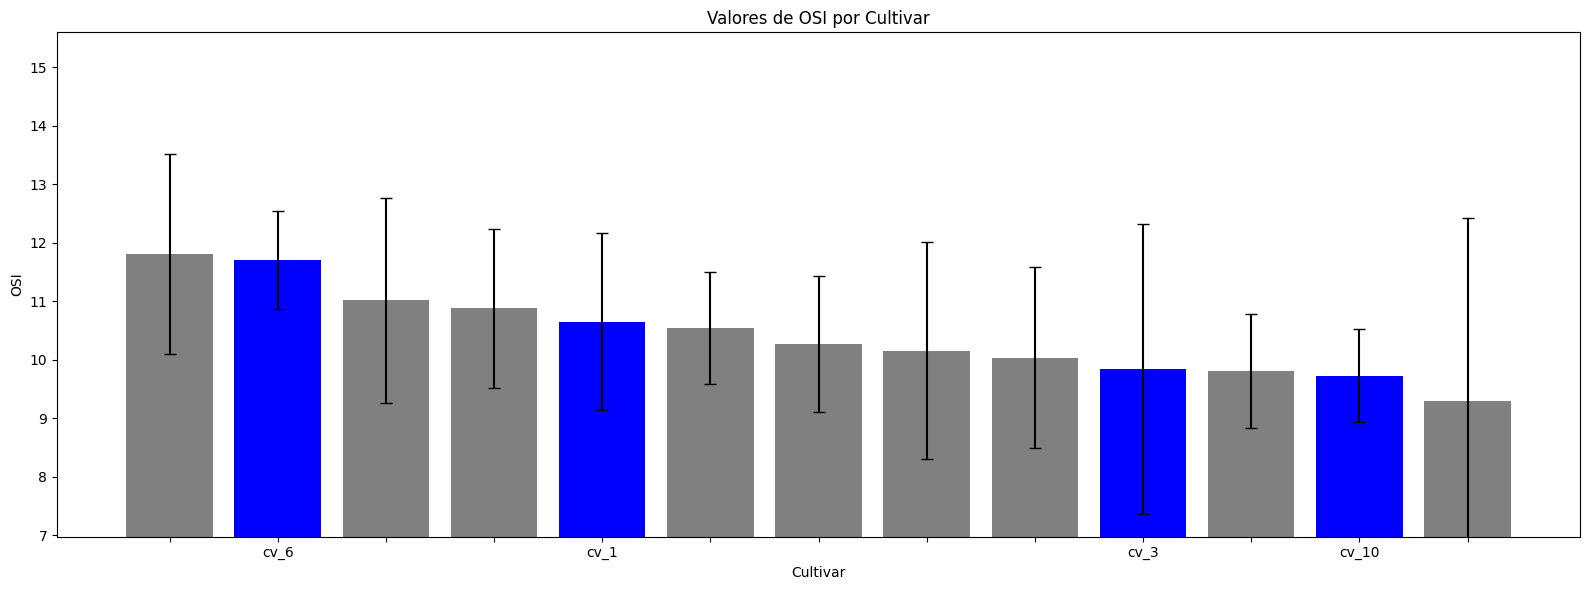

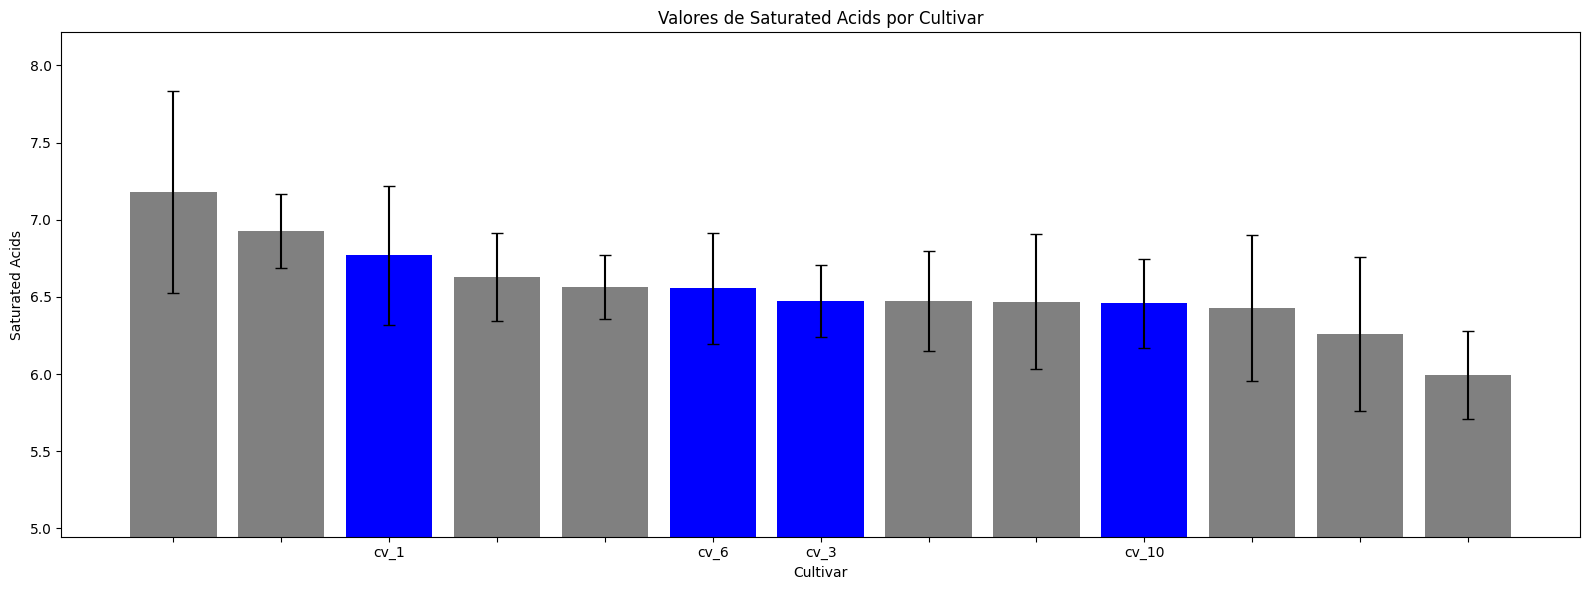

In [ ]:
for col in columns_to_compare:
    plot_selected_bar_chart(df_2_mean, col, top(df_2_mean, 'α+γ+δ Tocopherol')[1])